# Eval DQN models

## Import dependecies and recheck installation

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from torchinfo import summary
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
import pprint;
import pandas as pd
import os
import copy
import math
from pathlib import Path
from IPython.display import display, clear_output, HTML

import warnings

print("All dependencies imported successfully.")
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("CUDA not available. Using CPU.")

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

All dependencies imported successfully.
torch version: 2.5.1
CUDA available: True
CUDA version: 11.8
GPU name: NVIDIA GeForce RTX 4090
cuda


### Fixed Random seeds

In [2]:
SEED = 666
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

## Custom imports

In [3]:
from C4.connect4_env import Connect4Env
from C4.fast_connect4_lookahead import Connect4Lookahead
from PPO.ppo_training_phases_config import TRAINING_PHASES, validate_training_phases
from DQN.dueling_qnet192 import DuelingQNet192
from PPO.phase_tracker import PhaseTracker, display_phases_table
from C4.CNet192 import CNet192, save_cnet192, load_cnet192
from C4.connect4_env import Connect4Env
from C4.opening_tracker import OpeningTracker, init_opening_kpis, record_first_move, summarize_opening_kpis
from DQN.dqn_utilities import update_benchmark_winrates, track_result, h2h_append, plot_live_training, plot_is_weights
from C4.connect4_board_display import display_final_boards_DQN
from C4.utilities import *
from PPO.ppo_opponent_sampler import OpponentSampler
from DQN.dqn_loop_helpers_1ch import (
    play_episode_dqn,
    track_result,
    select_opponent_actor,
)
from C4.eval_oppo_dict import *
from DQN.dqn_hall_of_fame import DQNHallOfFame
from DQN.dqn_diagnostics import *
from DQN.dqn_agent import DQNAgent, DQNHyperParams, save_dqn_checkpoint
from DQN.dqn_replay_memory_per import *
from DQN.dqn_phase_manager import PhaseManager
from DQN.dqn_h2h import head_to_head_models
from DQN.dqn_hall_of_fame import DQNHallOfFame
from DQN.dqn_agent_eval import evaluate_and_log_to_excel, plot_eval_bar_summary_from_suite_df

print("Imports succesfull!")

Lookahead = Connect4Lookahead()
env = Connect4Env()

Imports succesfull!


## Constants

In [4]:
# LOG_DIR ="Logs/DQN/"
# MODEL_DIR ="Models/DQN/"
PLOTS = "Plots/DQN/"
# TEMP_DIR ="Models/DQN/TEMP/"           
# reset_dir(TEMP_DIR)   

In [5]:
begin_start_time = time.time()
model_path = "DQN_Models/DQN_601.pt" 
#model_path = "SupervisedModels/BASE_6.pt" #
#model_name = model_path.split("/")[-1].split(".")[0]
TRAINING_SESSION = model_path.split("/")[-1].split(".")[0]
print("Start eval session", TRAINING_SESSION)

Start eval session DQN_601


# Load

In [6]:
hp = DQNHyperParams(
    lr=2e-4, gamma=0.99,
    epsilon=0.0, epsilon_min=0.0, epsilon_decay=1.0,   # eval: typically no exploration
    batch_size=256,
    per_mix_1step=1.0,
    target_update_mode="soft",
    tau=0.005,
)

agent, ckpt = DQNAgent.from_dqn_checkpoint(
    ckpt_path=model_path,
    device=DEVICE,
    strict=True,
    freeze_conv=True,          # optional for eval, harmless
    hparams=hp,
    seed=0,
    load_optimizer=False,
    load_target=True,
)

agent.q_net.eval()
agent.target_net.eval()
print("Loaded DQN checkpoint:", model_path)
print("Meta:", ckpt.get("meta", {}))

C:\Users\Uporabnik\Documents\JS\Connect4\Code\Jupiter\Connect4\DQN\dqn_agent.py:258: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(ckpt_path, map_location=d

Loaded DQN checkpoint: DQN_Models/DQN_601.pt
Meta: {'tag': 'H2H_best', 'session': 'PPO-3000-POP-SP_final-BASE_6 - at-2026-02-20 21-43-05', 'phase': 'L5_focus', 'episode': 860, 'seed': 1526, 'score': 0.5, 't': 1771624239.3890314}


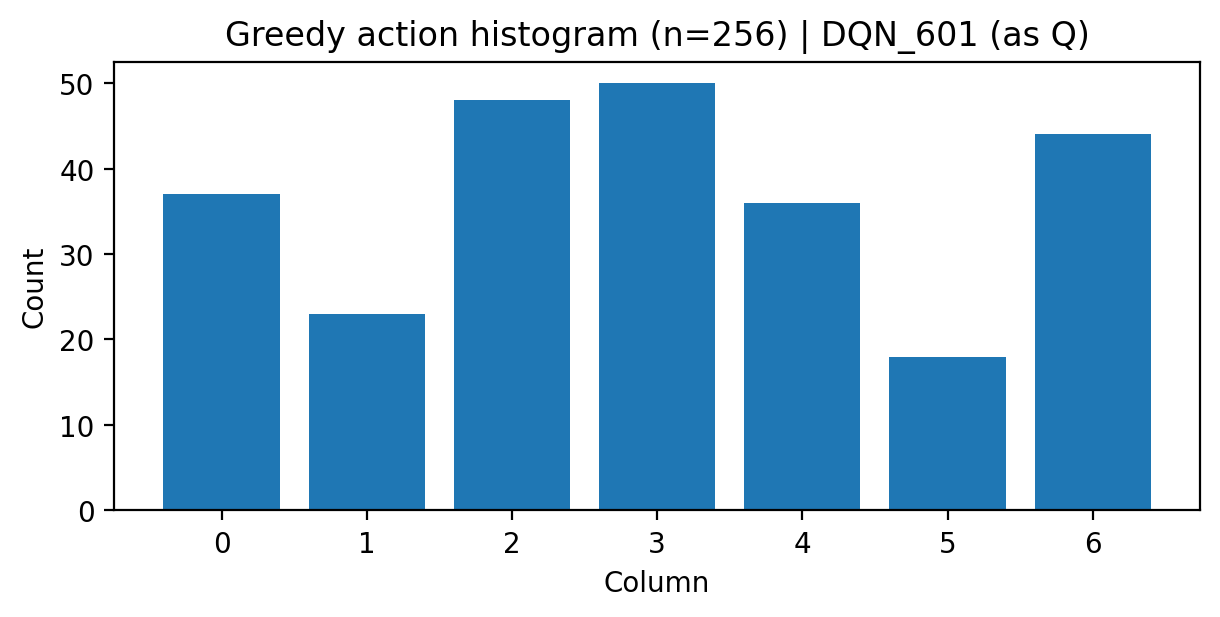

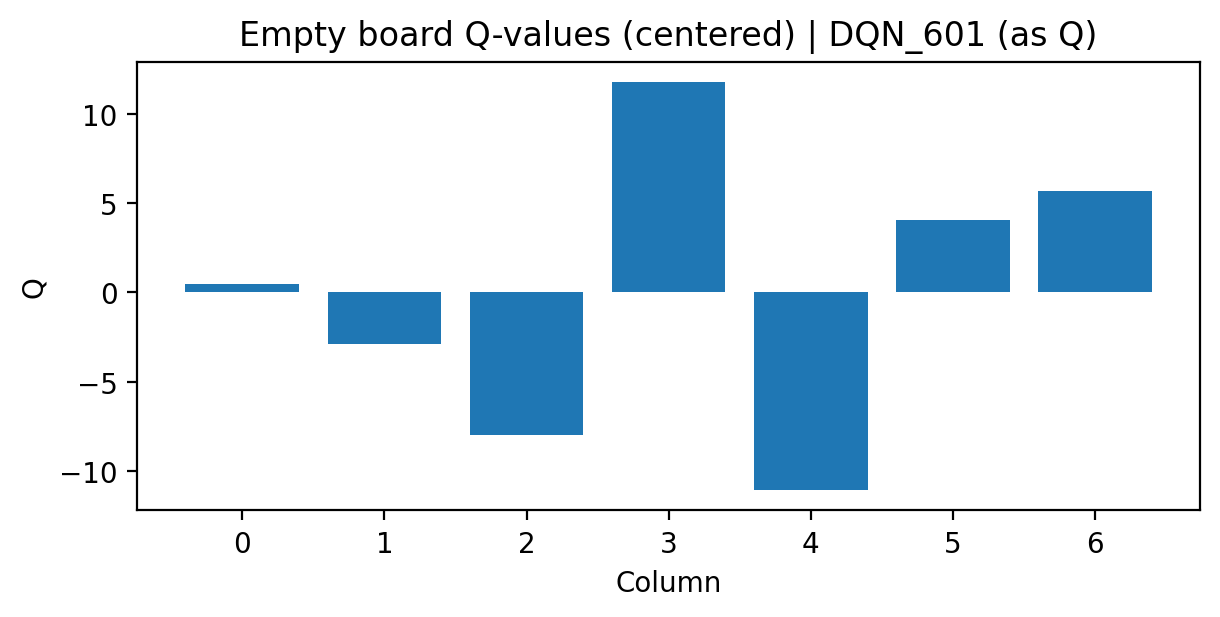

In [7]:
counts, q0, fig_hist, fig_q0, _ = run_quick_diagnostics(
    agent.q_net,
    env,
    device=DEVICE,
    model_name=f"{TRAINING_SESSION} (as Q)",
    n_states=256,
    max_ply=18,
    seed=666,
)

display(fig_hist)
display(fig_q0)

# Evaluation

In [8]:
print("agent type:", type(agent))
print("has board_to_state:", hasattr(agent, "board_to_state"))
print("has model/q_net:", hasattr(agent, "model"), hasattr(agent, "q_net"))
if hasattr(agent, "board_to_state"):
    print("board_to_state:", agent.board_to_state)

agent type: <class 'DQN.dqn_agent.DQNAgent'>
has board_to_state: True
has model/q_net: True True
board_to_state: <bound method DQNAgent.board_to_state of <DQN.dqn_agent.DQNAgent object at 0x000001B89DB274C0>>


Eval vs Random:   0%|          | 0/200 [00:00<?, ?it/s]

Eval vs Leftmost:   0%|          | 0/100 [00:00<?, ?it/s]

Eval vs Center:   0%|          | 0/200 [00:00<?, ?it/s]

Eval vs Lookahead-1:   0%|          | 0/100 [00:00<?, ?it/s]

Eval vs Lookahead-2:   0%|          | 0/100 [00:00<?, ?it/s]

...

Eval vs Lookahead-11:   0%|          | 0/4 [00:00<?, ?it/s]

Eval vs Lookahead-13:   0%|          | 0/4 [00:00<?, ?it/s]

,opponent,games,wins,losses,draws,win_rate,loss_rate,draw_rate,score,avg_plies
0,Random,200,199,1,0,0.995,0.005,0.0,0.995,11.945
1,Leftmost,100,100,0,0,1.000,0.000,0.0,1.000,8.500
2,Center,200,200,0,0,1.000,0.000,0.0,1.000,16.500
3,Lookahead-1,100,0,100,0,0.000,1.000,0.0,0.000,26.500
4,Lookahead-2,100,0,100,0,0.000,1.000,0.0,0.000,20.820
5,Lookahead-3,100,0,100,0,0.000,1.000,0.0,0.000,17.900
6,Lookahead-4,100,0,100,0,0.000,1.000,0.0,0.000,23.580
7,Lookahead-5,50,0,50,0,0.000,1.000,0.0,0.000,14.620
8,Lookahead-6,24,0,24,0,0.000,1.000,0.0,0.000,20.000
9,Lookahead-7,10,0,10,0,0.000,1.000,0.0,0.000,19.500


,TIME [h],EPISODES,Random,Leftmost,Center,Lookahead-1,Lookahead-2,Lookahead-3,Lookahead-4,Lookahead-5,Lookahead-6,Lookahead-7,Lookahead-9,Lookahead-11,Lookahead-13,GLOBAL_SCORE
TRAINING_SESSION,,,,,,,,,,,,,,,,
DQN_601,0.016945,0,0.995,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.355684


[Saved] Plots/DQN/DQN-DQN_601-evaluation_plot.png


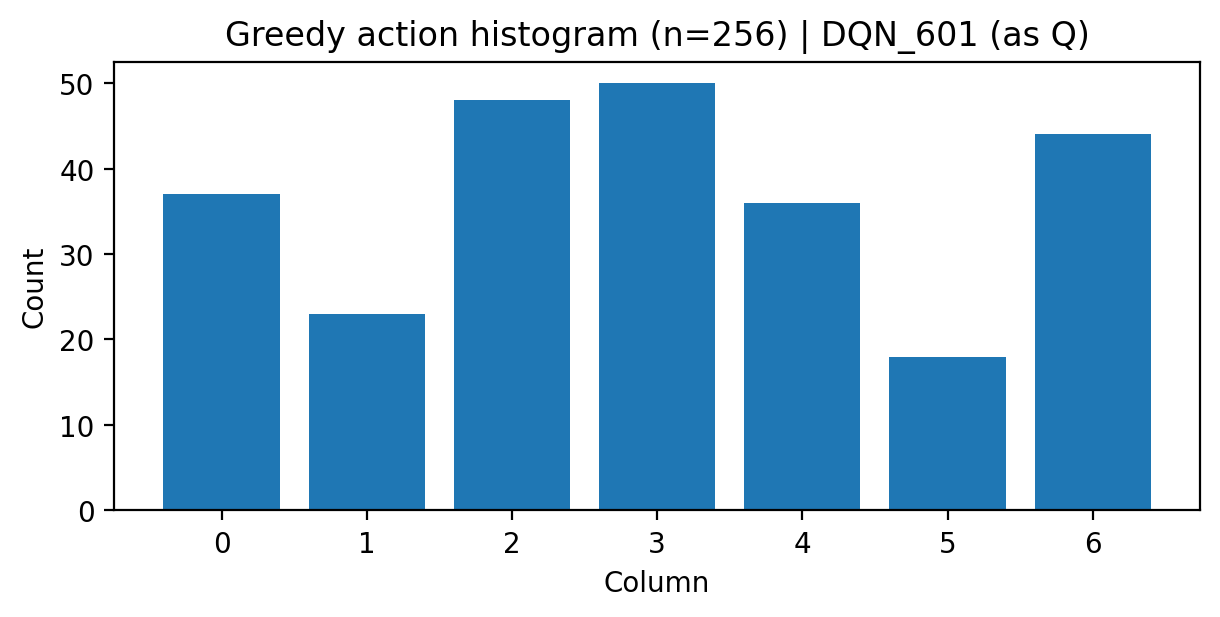

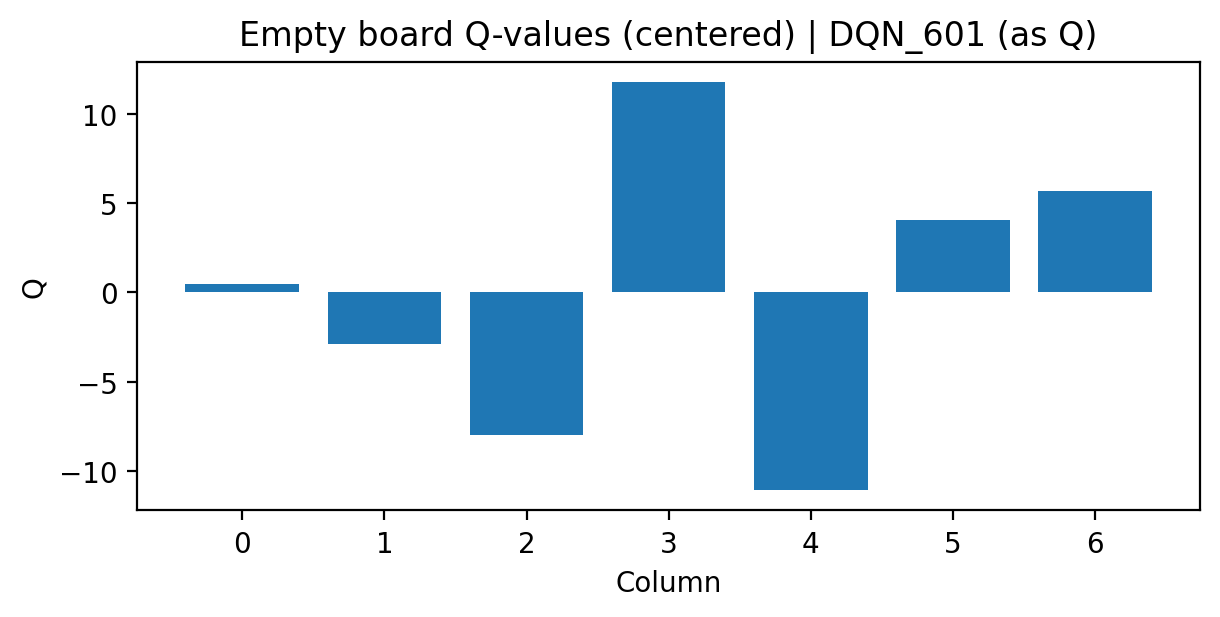

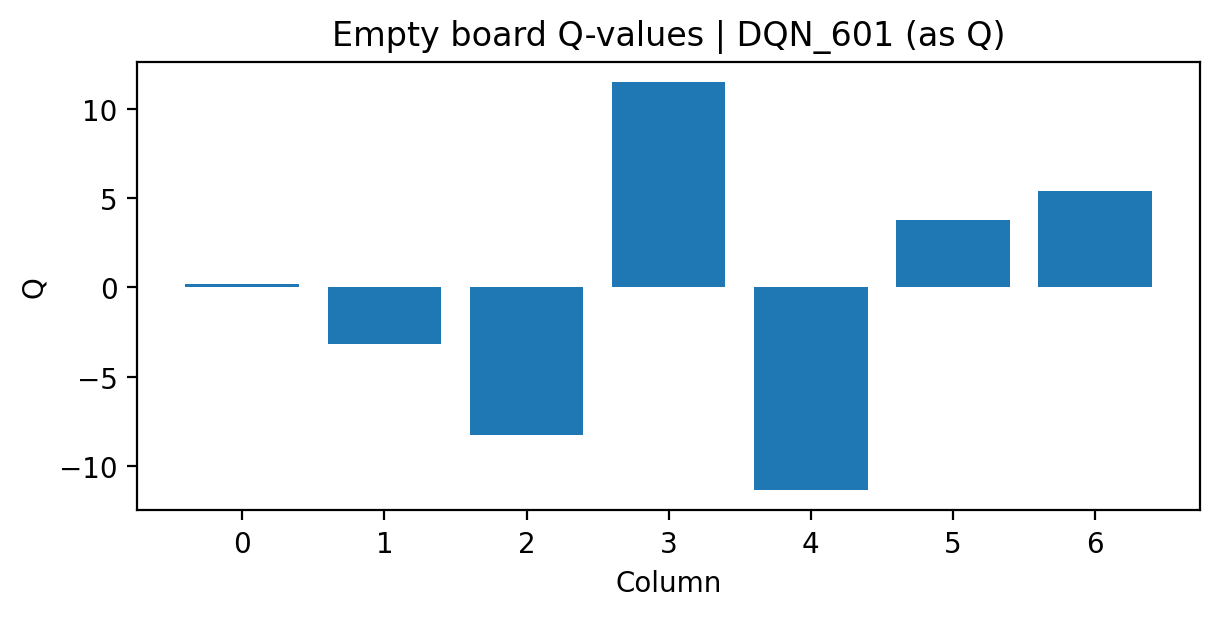

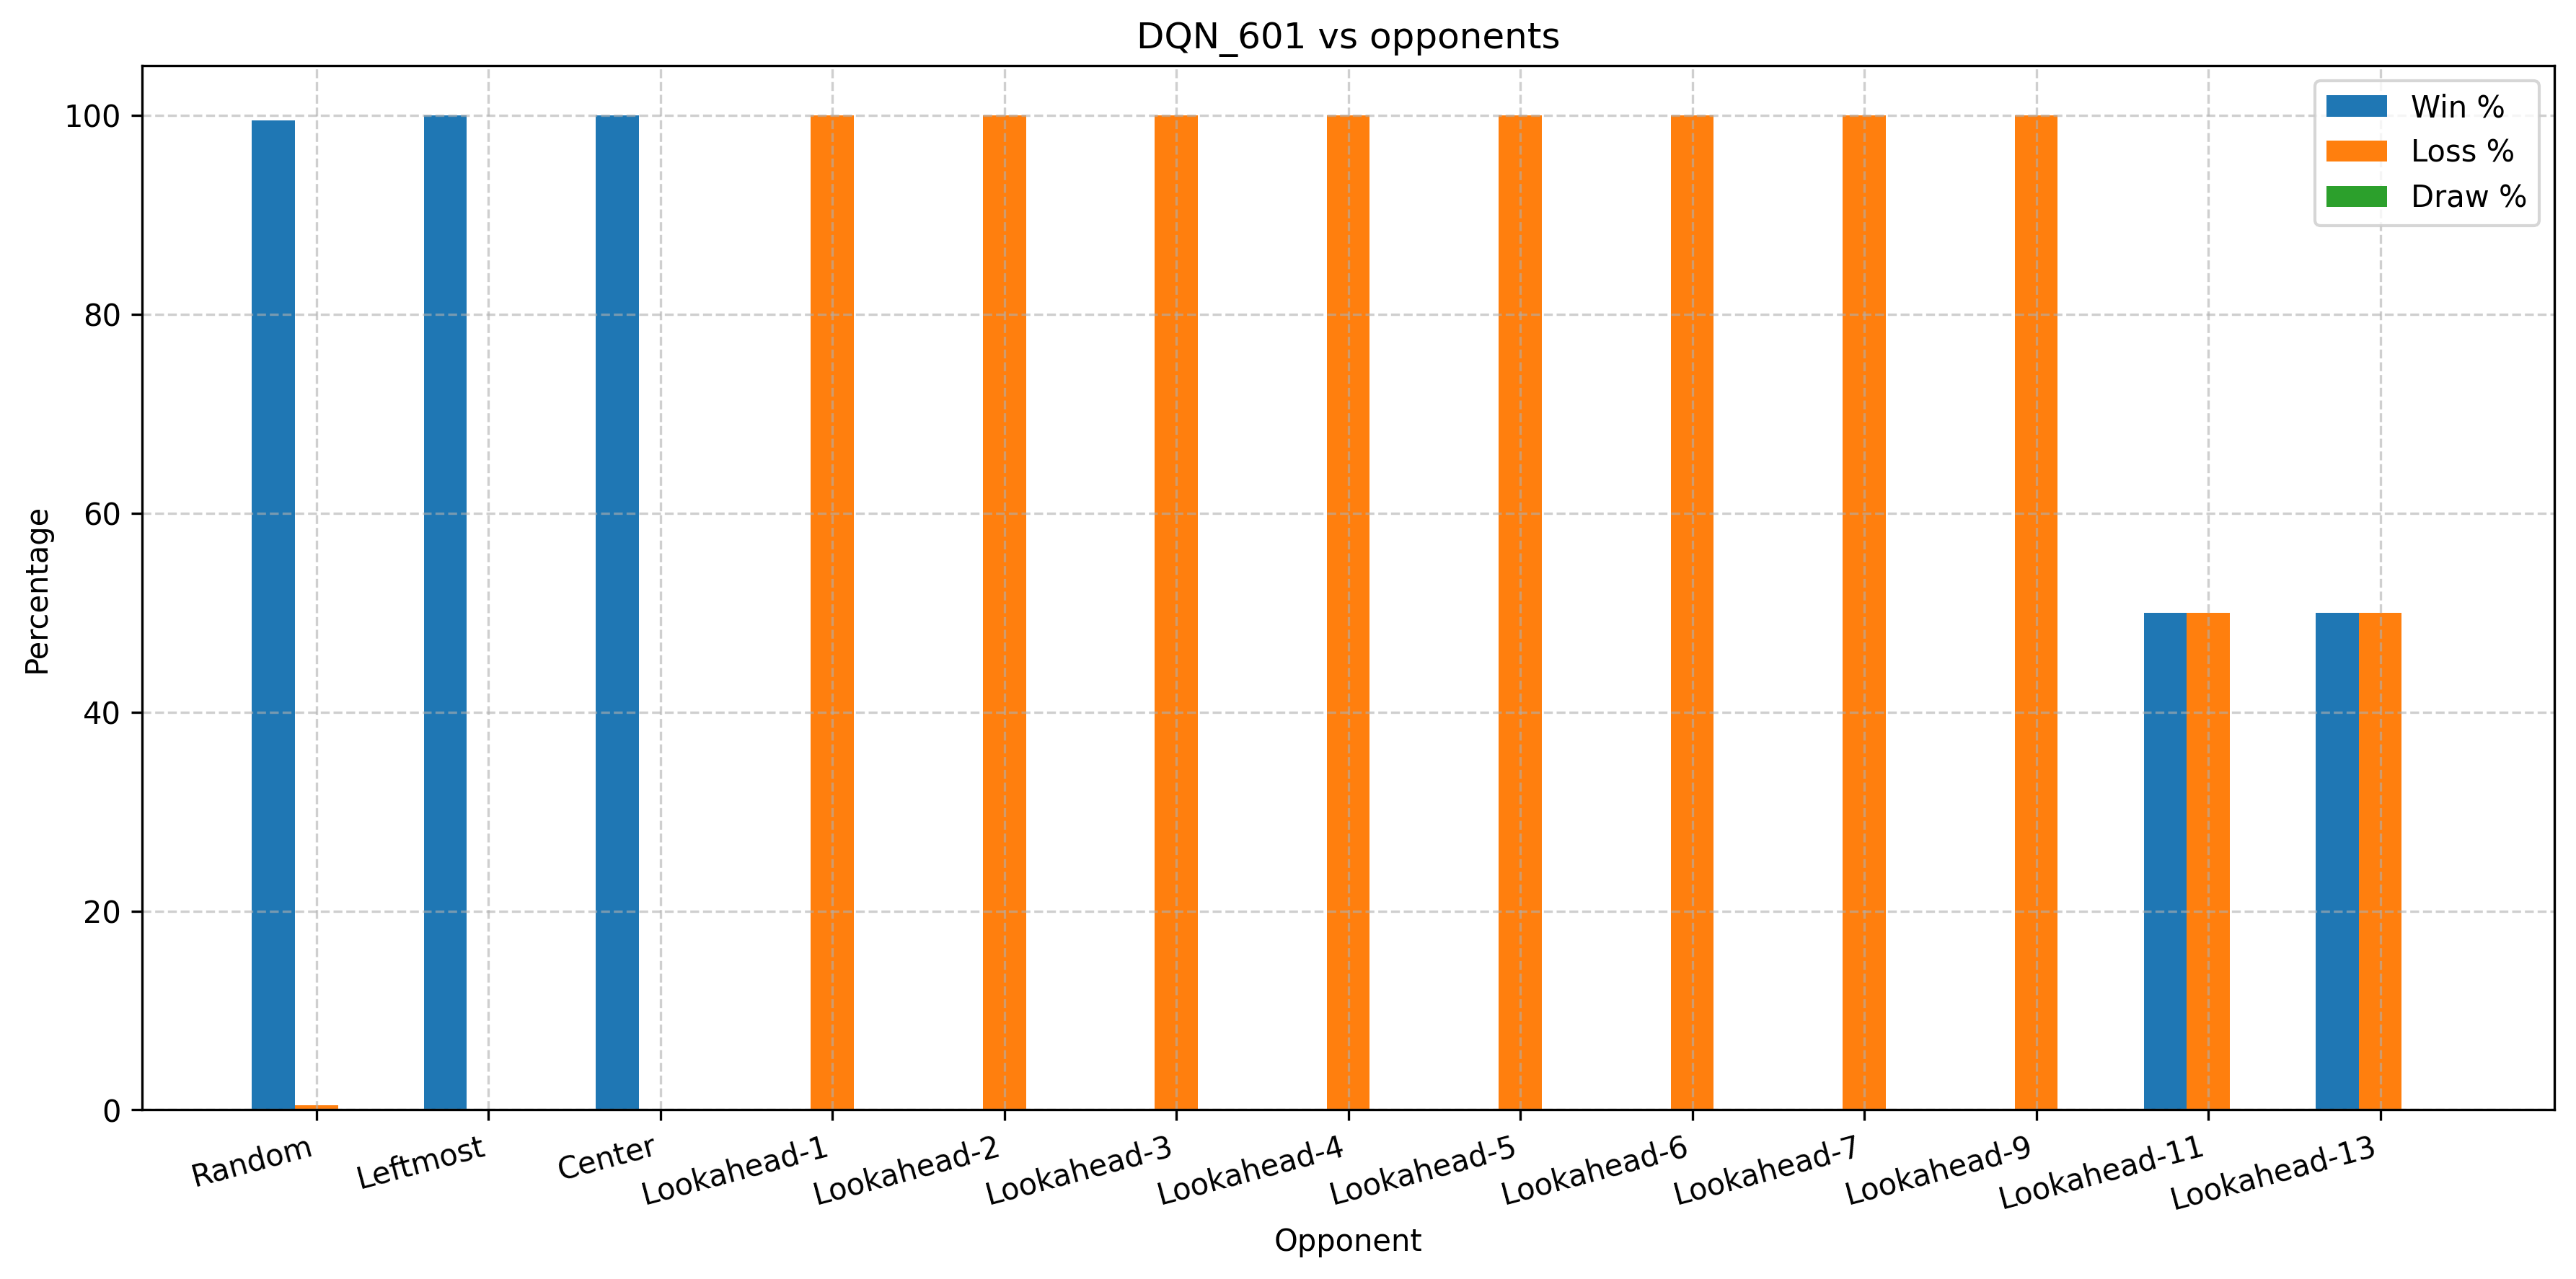

In [9]:
suite_df, row_df = evaluate_and_log_to_excel(
    agent=agent,
    opponents_cfg=EVALUATION_OPPONENTS,
    excel_path="EVAL_DQN_results.xlsx",
    run_tag=TRAINING_SESSION,
    device=DEVICE,
    lookahead=Lookahead,          
    seed=SEED,
    episodes=0,                  
    progress=True,
    check_score=None,
    ensemble_score=None,
    center_rate=None,
)

display(suite_df)
display(row_df)

fig = plot_eval_bar_summary_from_suite_df(
    suite_df,
    model_name=TRAINING_SESSION,
    save_path=f"{PLOTS}DQN-{TRAINING_SESSION}-evaluation_plot.png",
)

import matplotlib.pyplot as plt
plt.show(fig)

In [10]:
display(suite_df)

,opponent,games,wins,losses,draws,win_rate,loss_rate,draw_rate,score,avg_plies
0,Random,200,199,1,0,0.995,0.005,0.0,0.995,11.945
1,Leftmost,100,100,0,0,1.000,0.000,0.0,1.000,8.500
2,Center,200,200,0,0,1.000,0.000,0.0,1.000,16.500
3,Lookahead-1,100,0,100,0,0.000,1.000,0.0,0.000,26.500
4,Lookahead-2,100,0,100,0,0.000,1.000,0.0,0.000,20.820
5,Lookahead-3,100,0,100,0,0.000,1.000,0.0,0.000,17.900
6,Lookahead-4,100,0,100,0,0.000,1.000,0.0,0.000,23.580
7,Lookahead-5,50,0,50,0,0.000,1.000,0.0,0.000,14.620
8,Lookahead-6,24,0,24,0,0.000,1.000,0.0,0.000,20.000
9,Lookahead-7,10,0,10,0,0.000,1.000,0.0,0.000,19.500


In [11]:
display(row_df)

,TIME [h],EPISODES,Random,Leftmost,Center,Lookahead-1,Lookahead-2,Lookahead-3,Lookahead-4,Lookahead-5,Lookahead-6,Lookahead-7,Lookahead-9,Lookahead-11,Lookahead-13,GLOBAL_SCORE
TRAINING_SESSION,,,,,,,,,,,,,,,,
DQN_601,0.016945,0,0.995,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.355684


[Saved] Plots/DQN/DQN-DQN_601-evaluation_plot.png


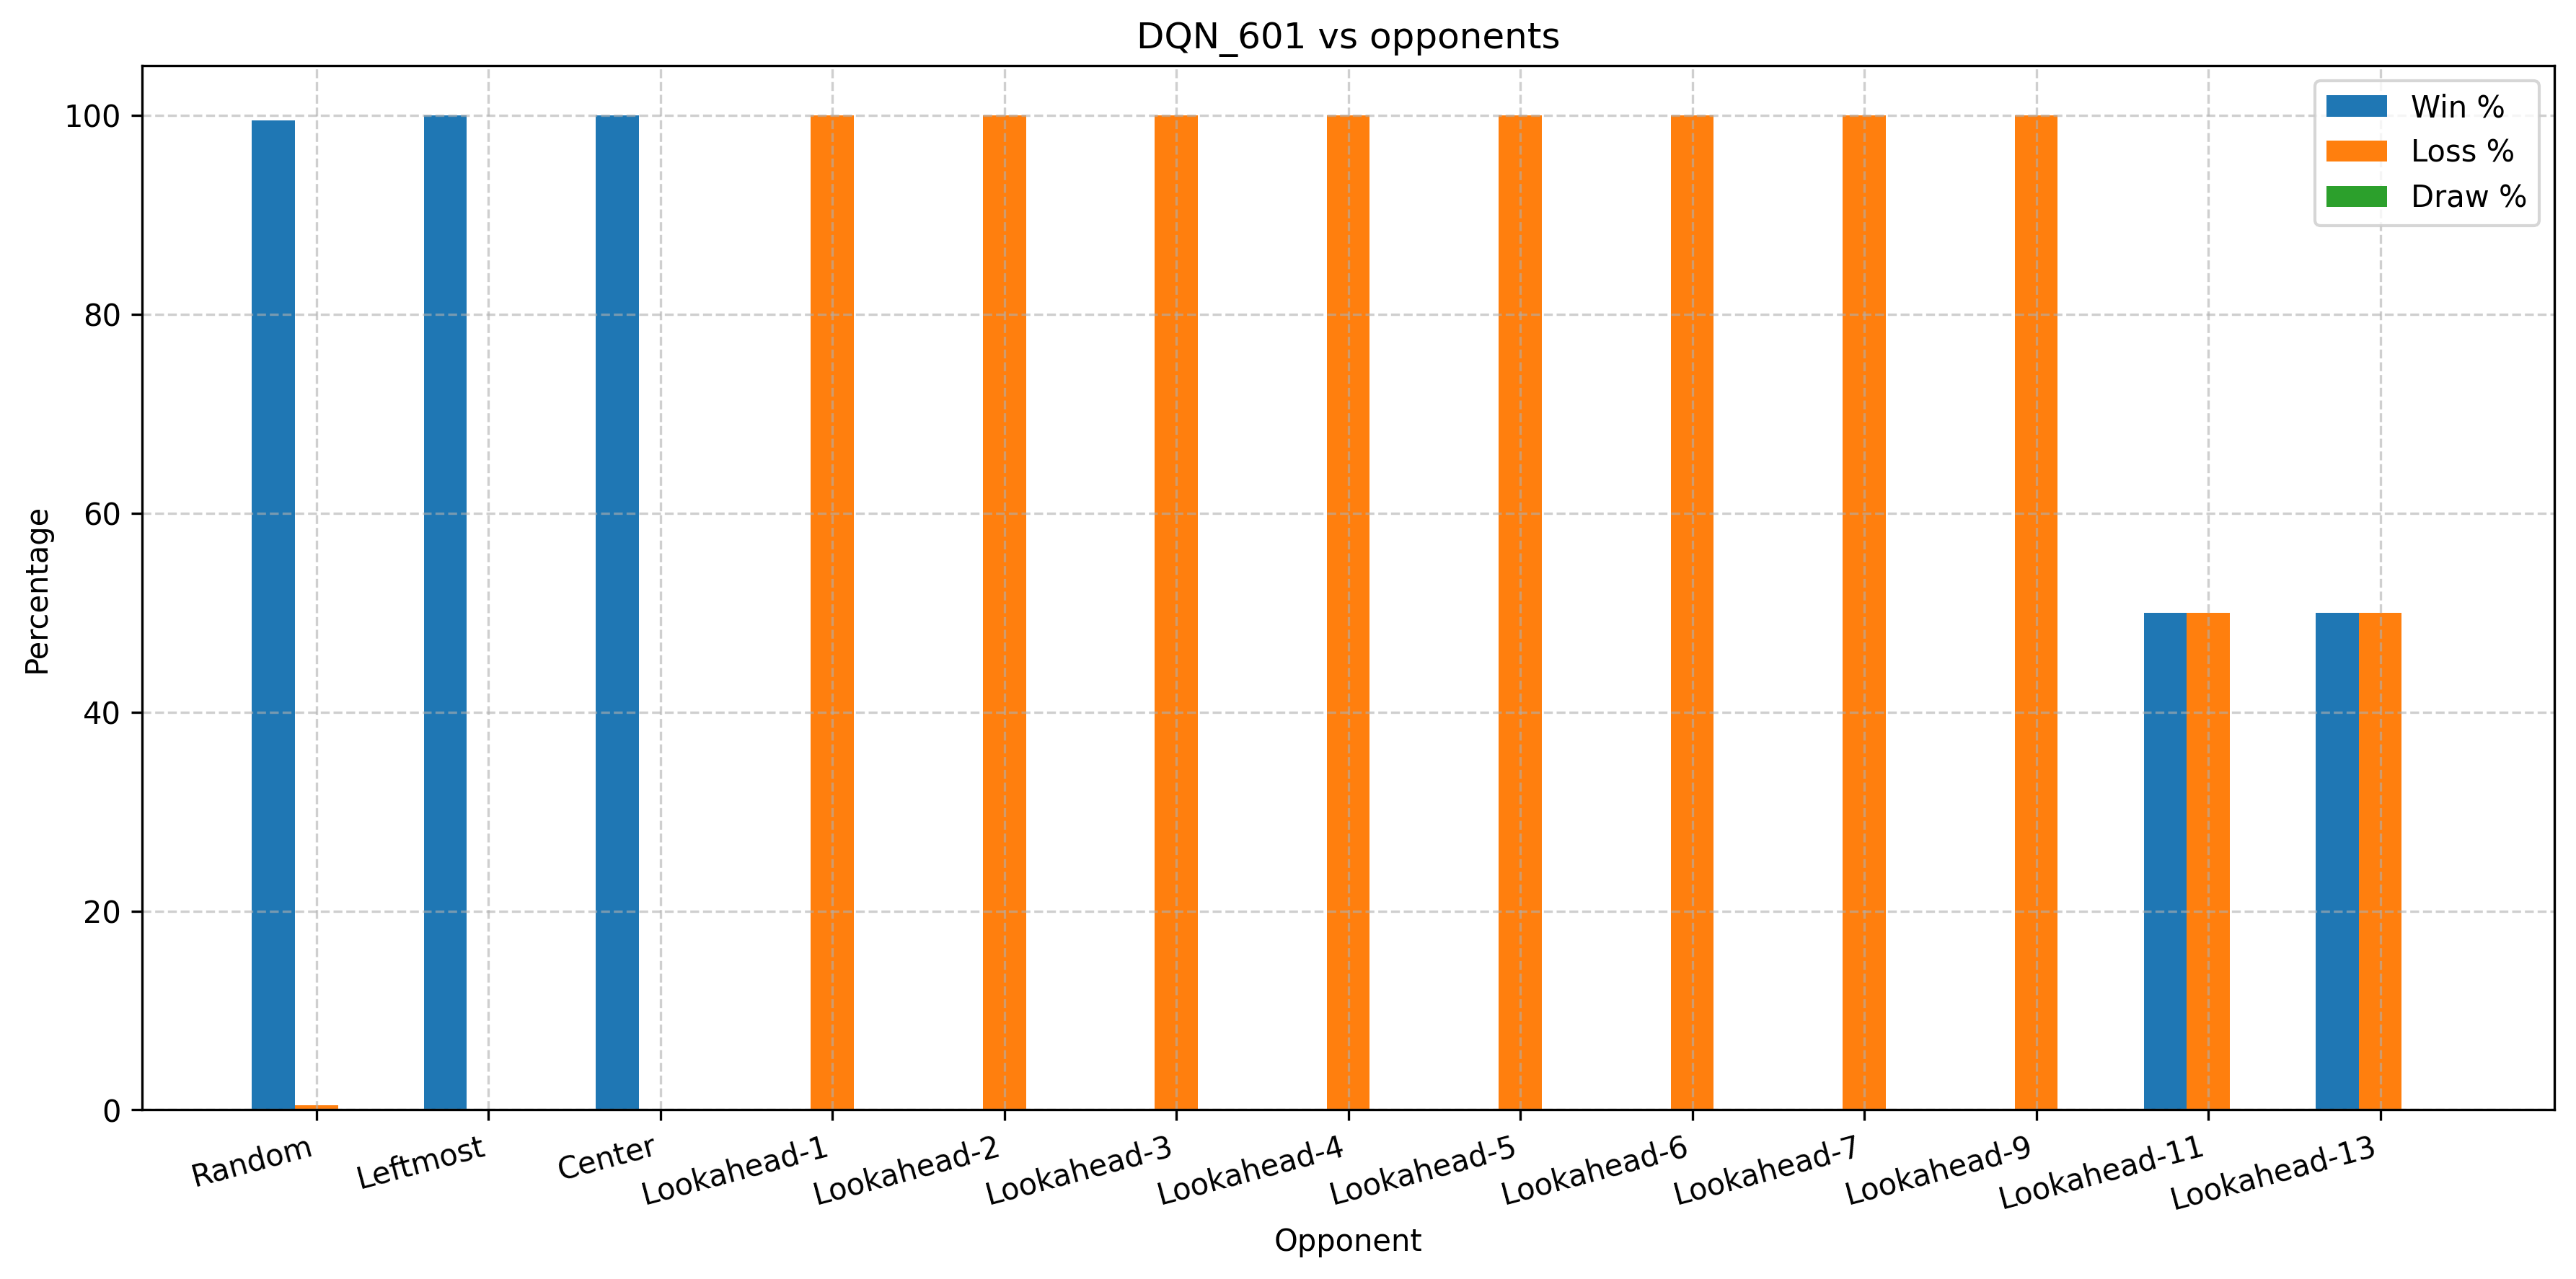

In [12]:
fig = plot_eval_bar_summary_from_suite_df(
    suite_df,
    model_name=TRAINING_SESSION,
    save_path=f"{PLOTS}DQN-{TRAINING_SESSION}-evaluation_plot.png",
)

plt.show(fig)

### Boards

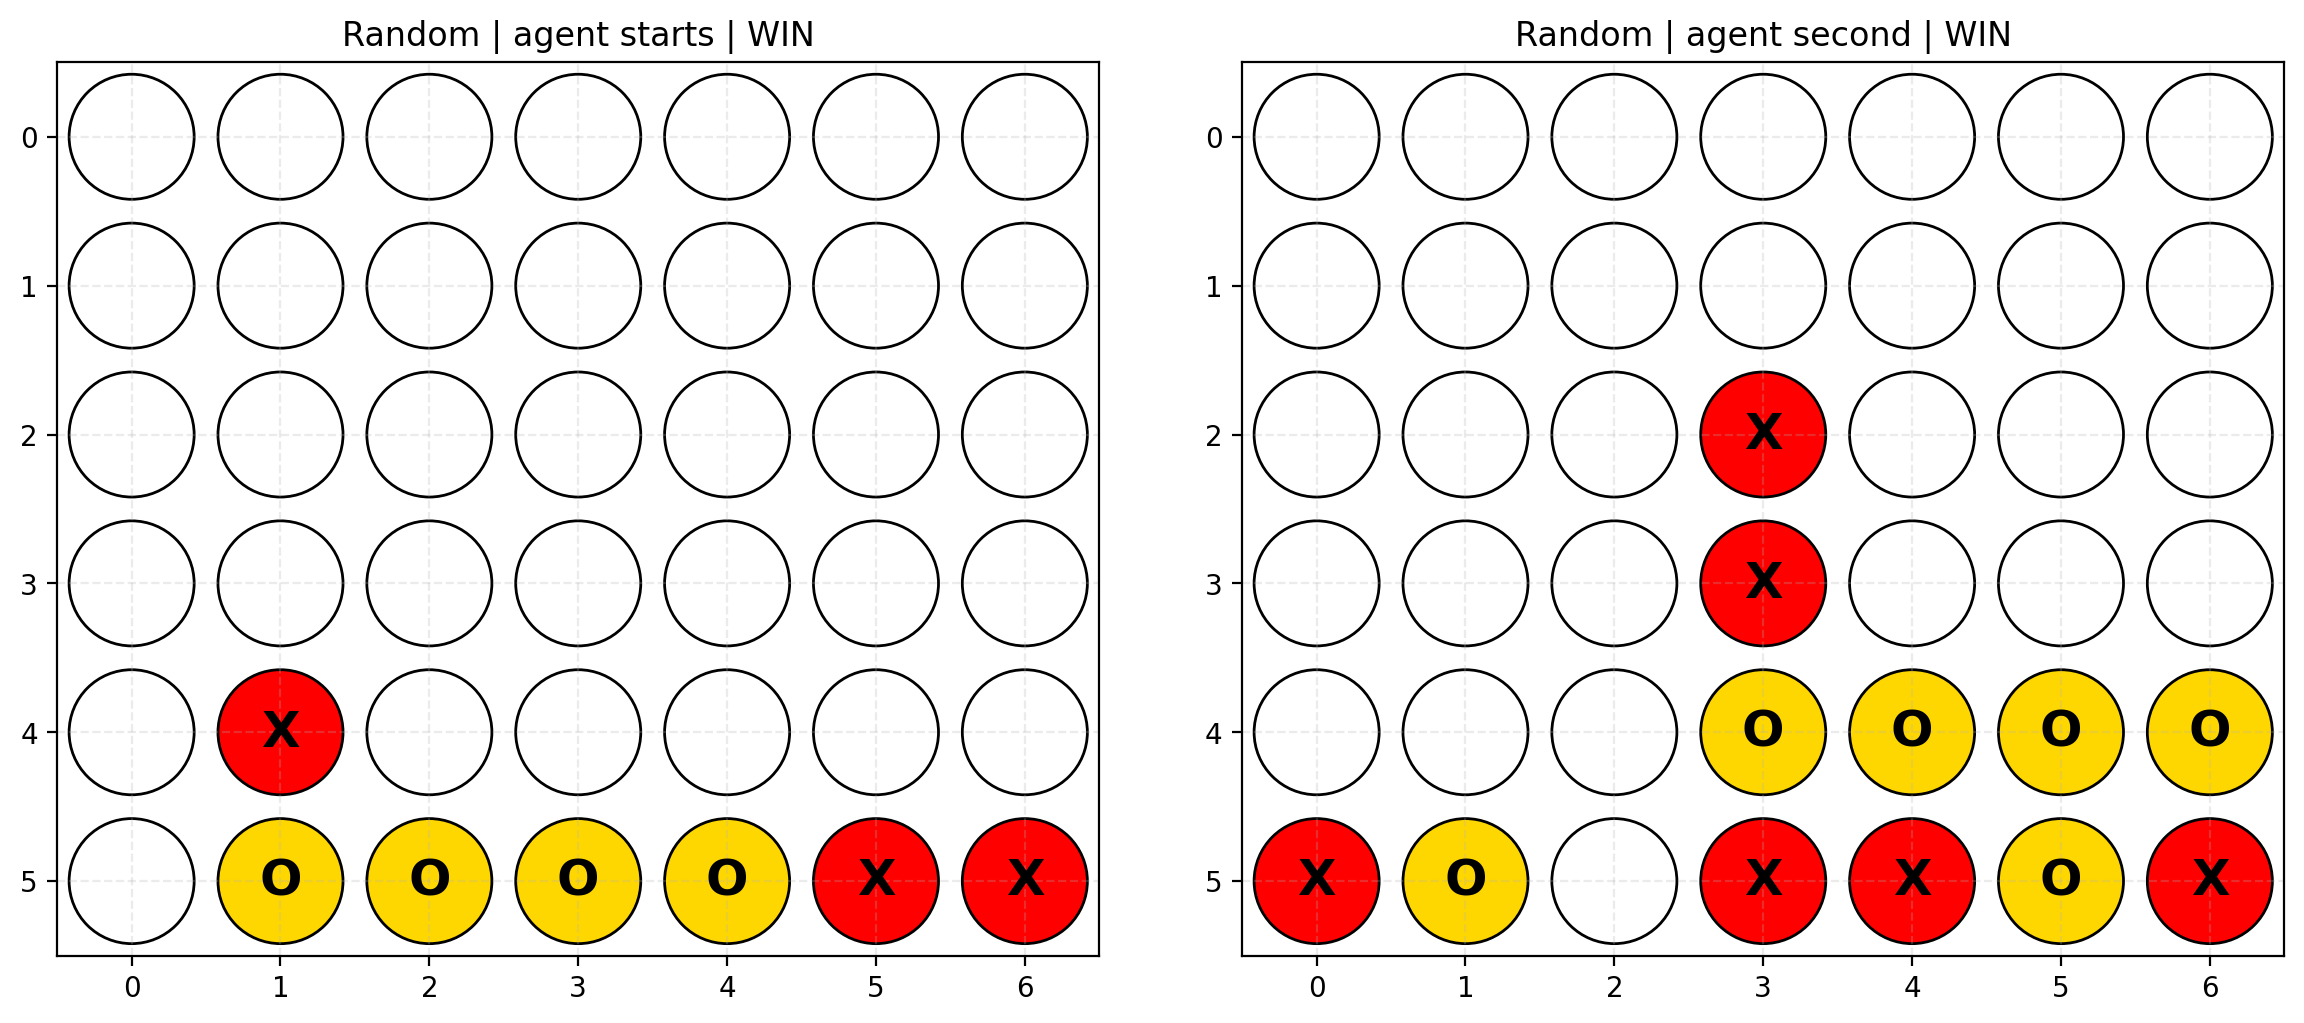

In [13]:
display_final_boards_DQN(agent, ["Random"])

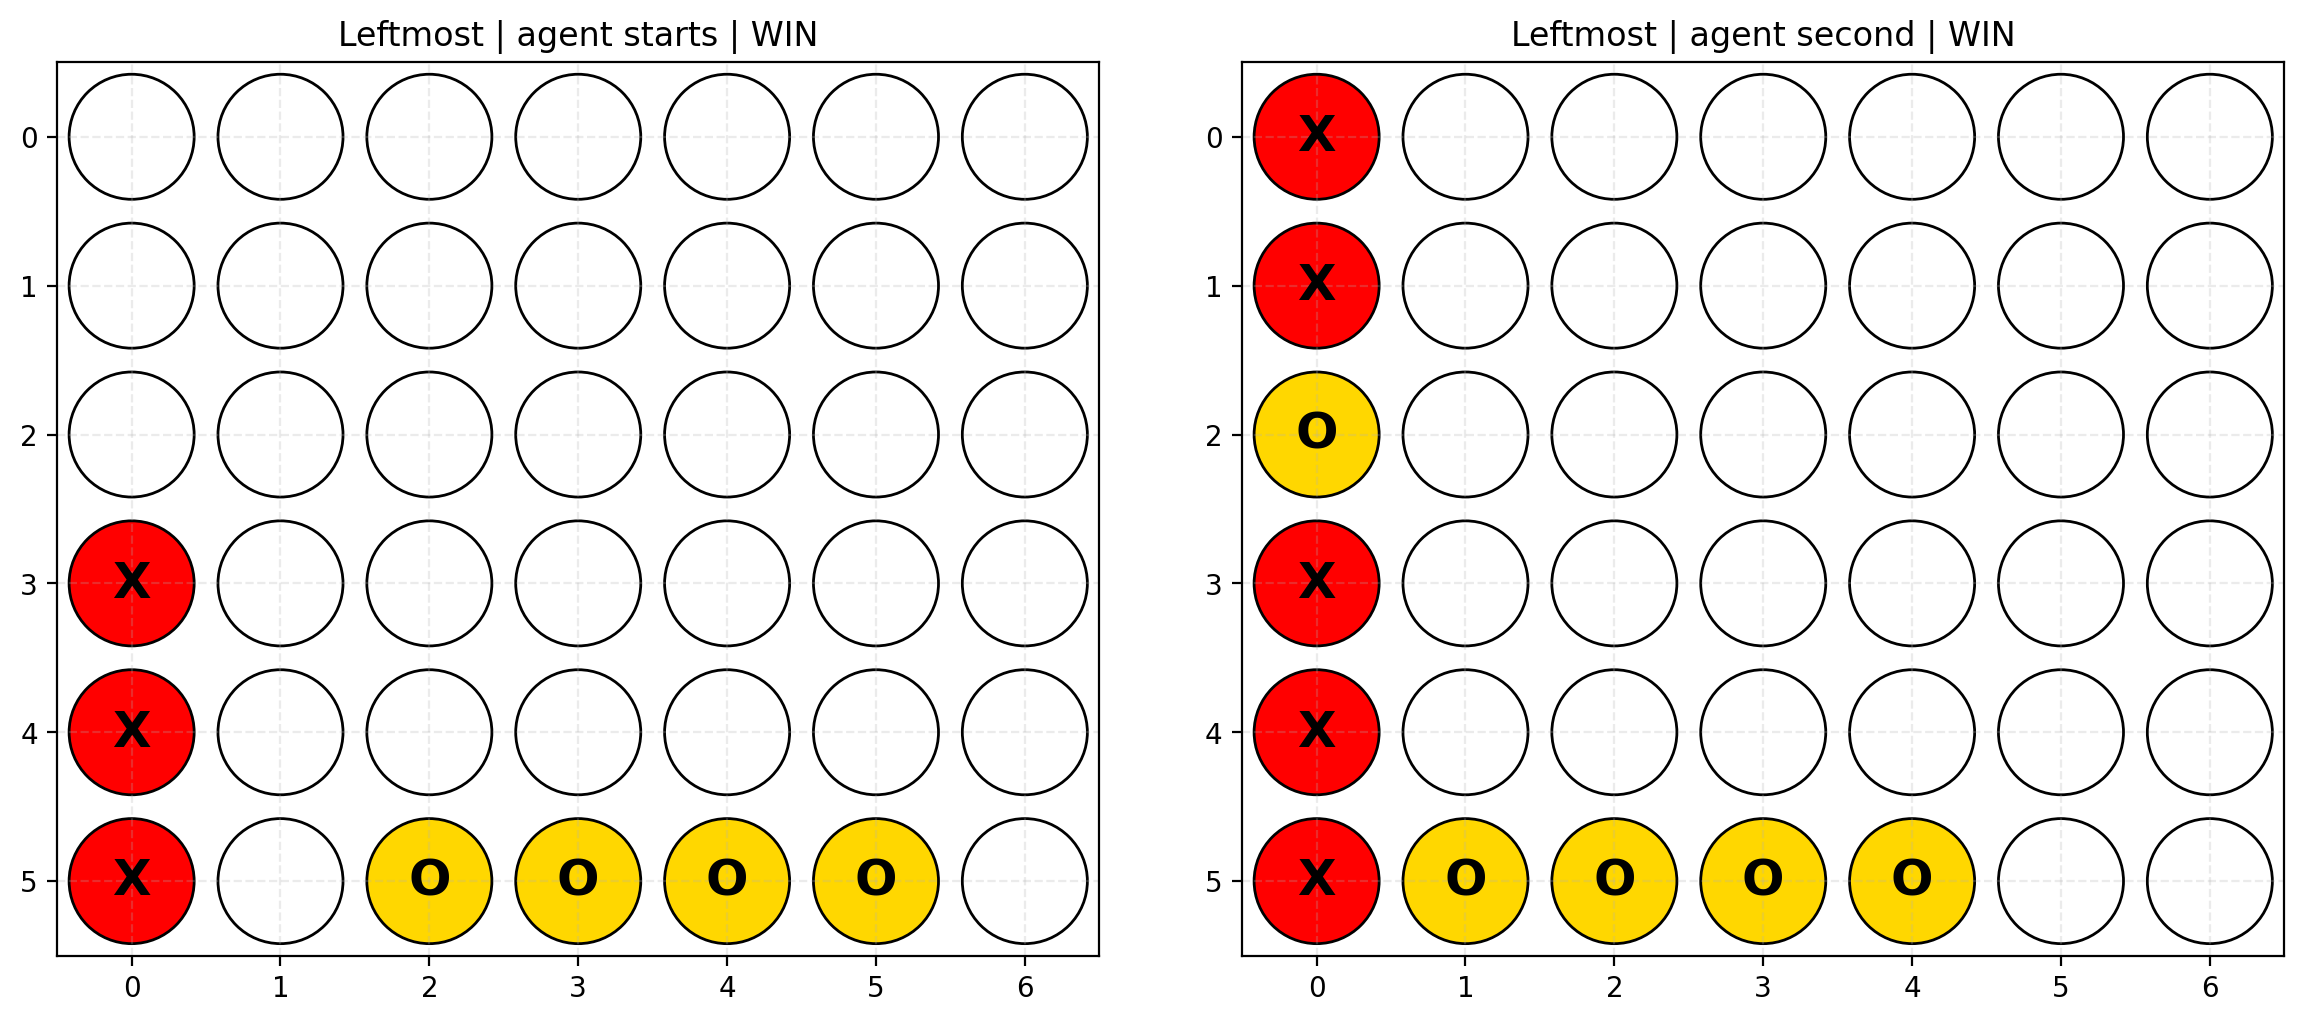

In [14]:
display_final_boards_DQN(agent, ["Leftmost"])

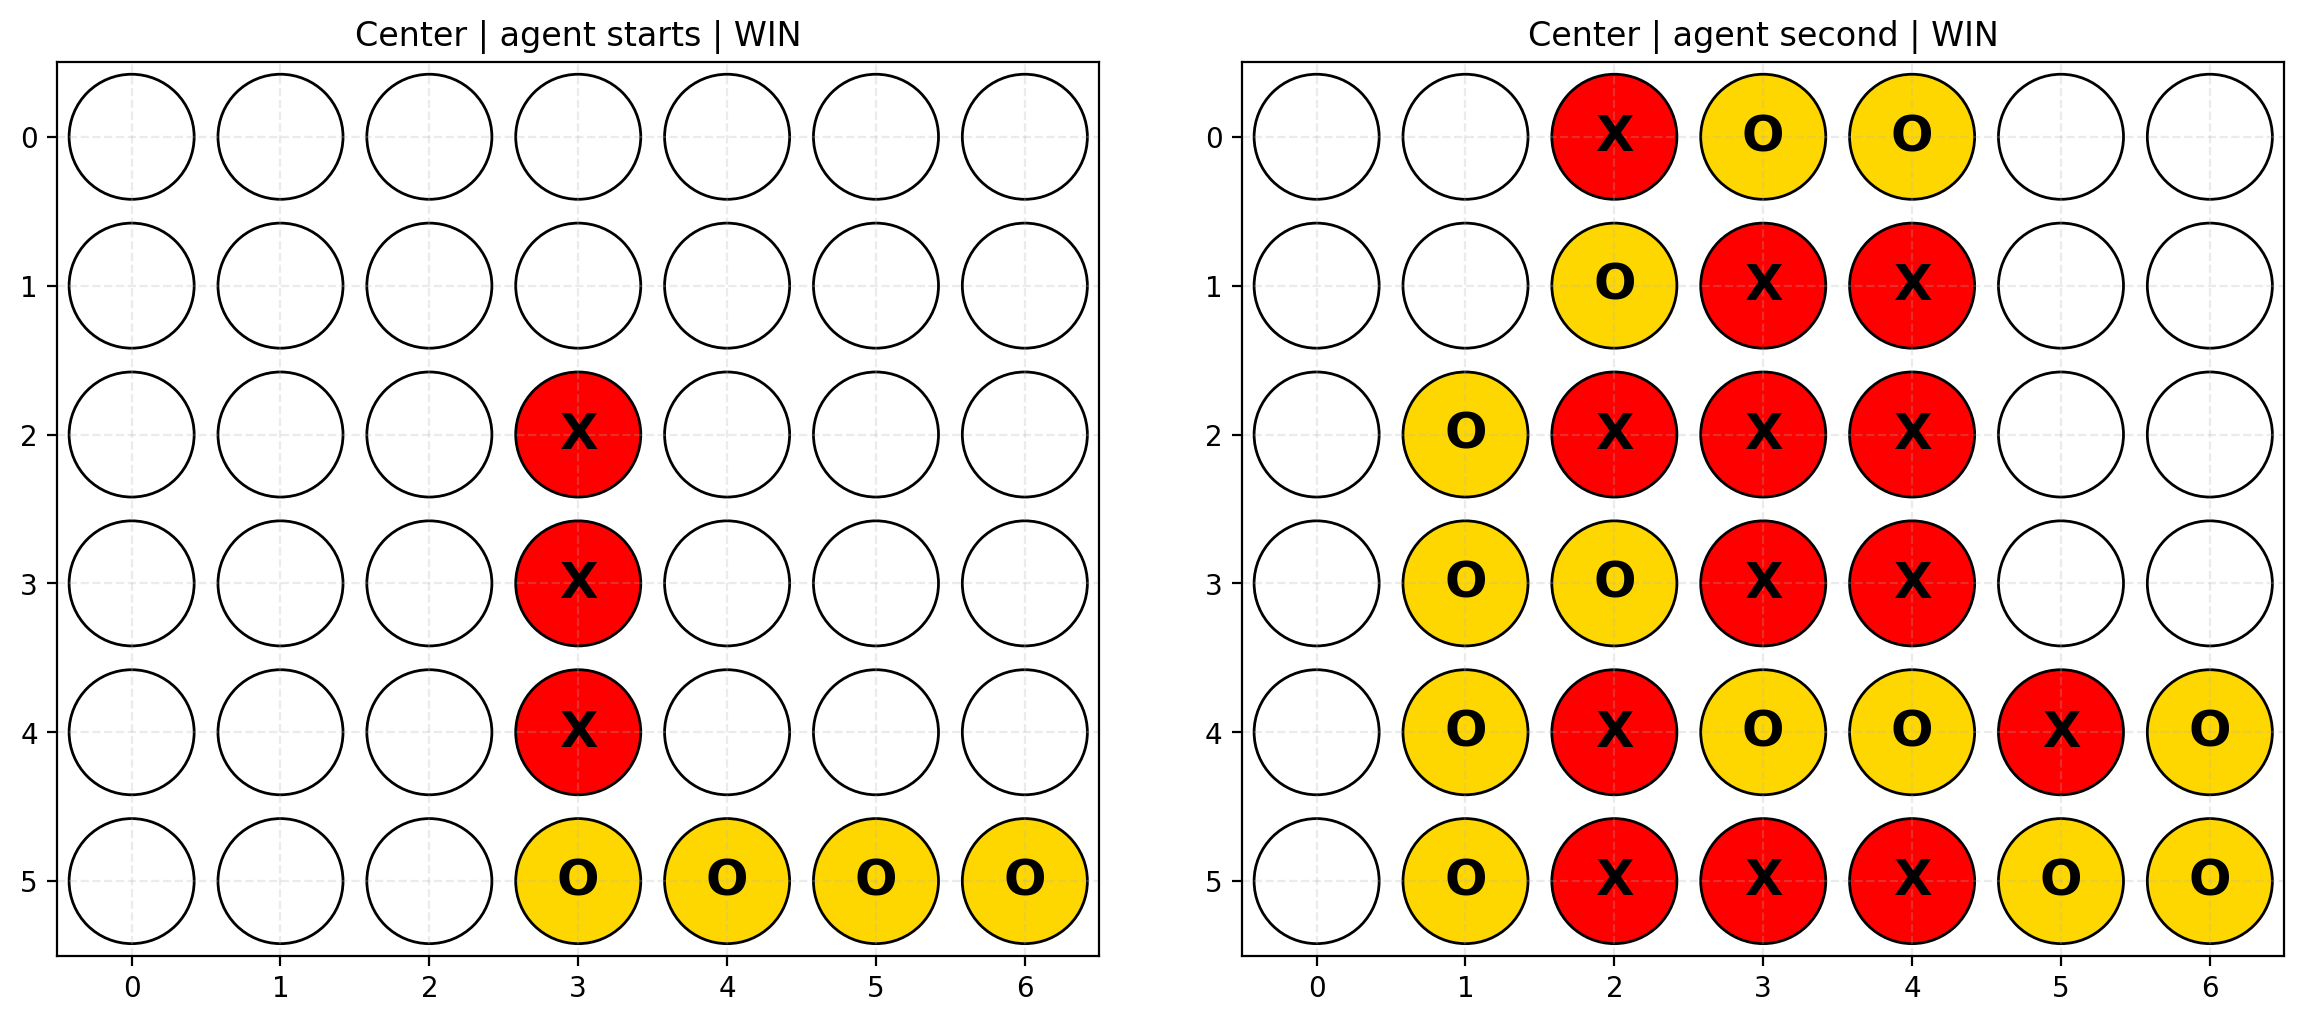

In [15]:
display_final_boards_DQN(agent, ["Center"])

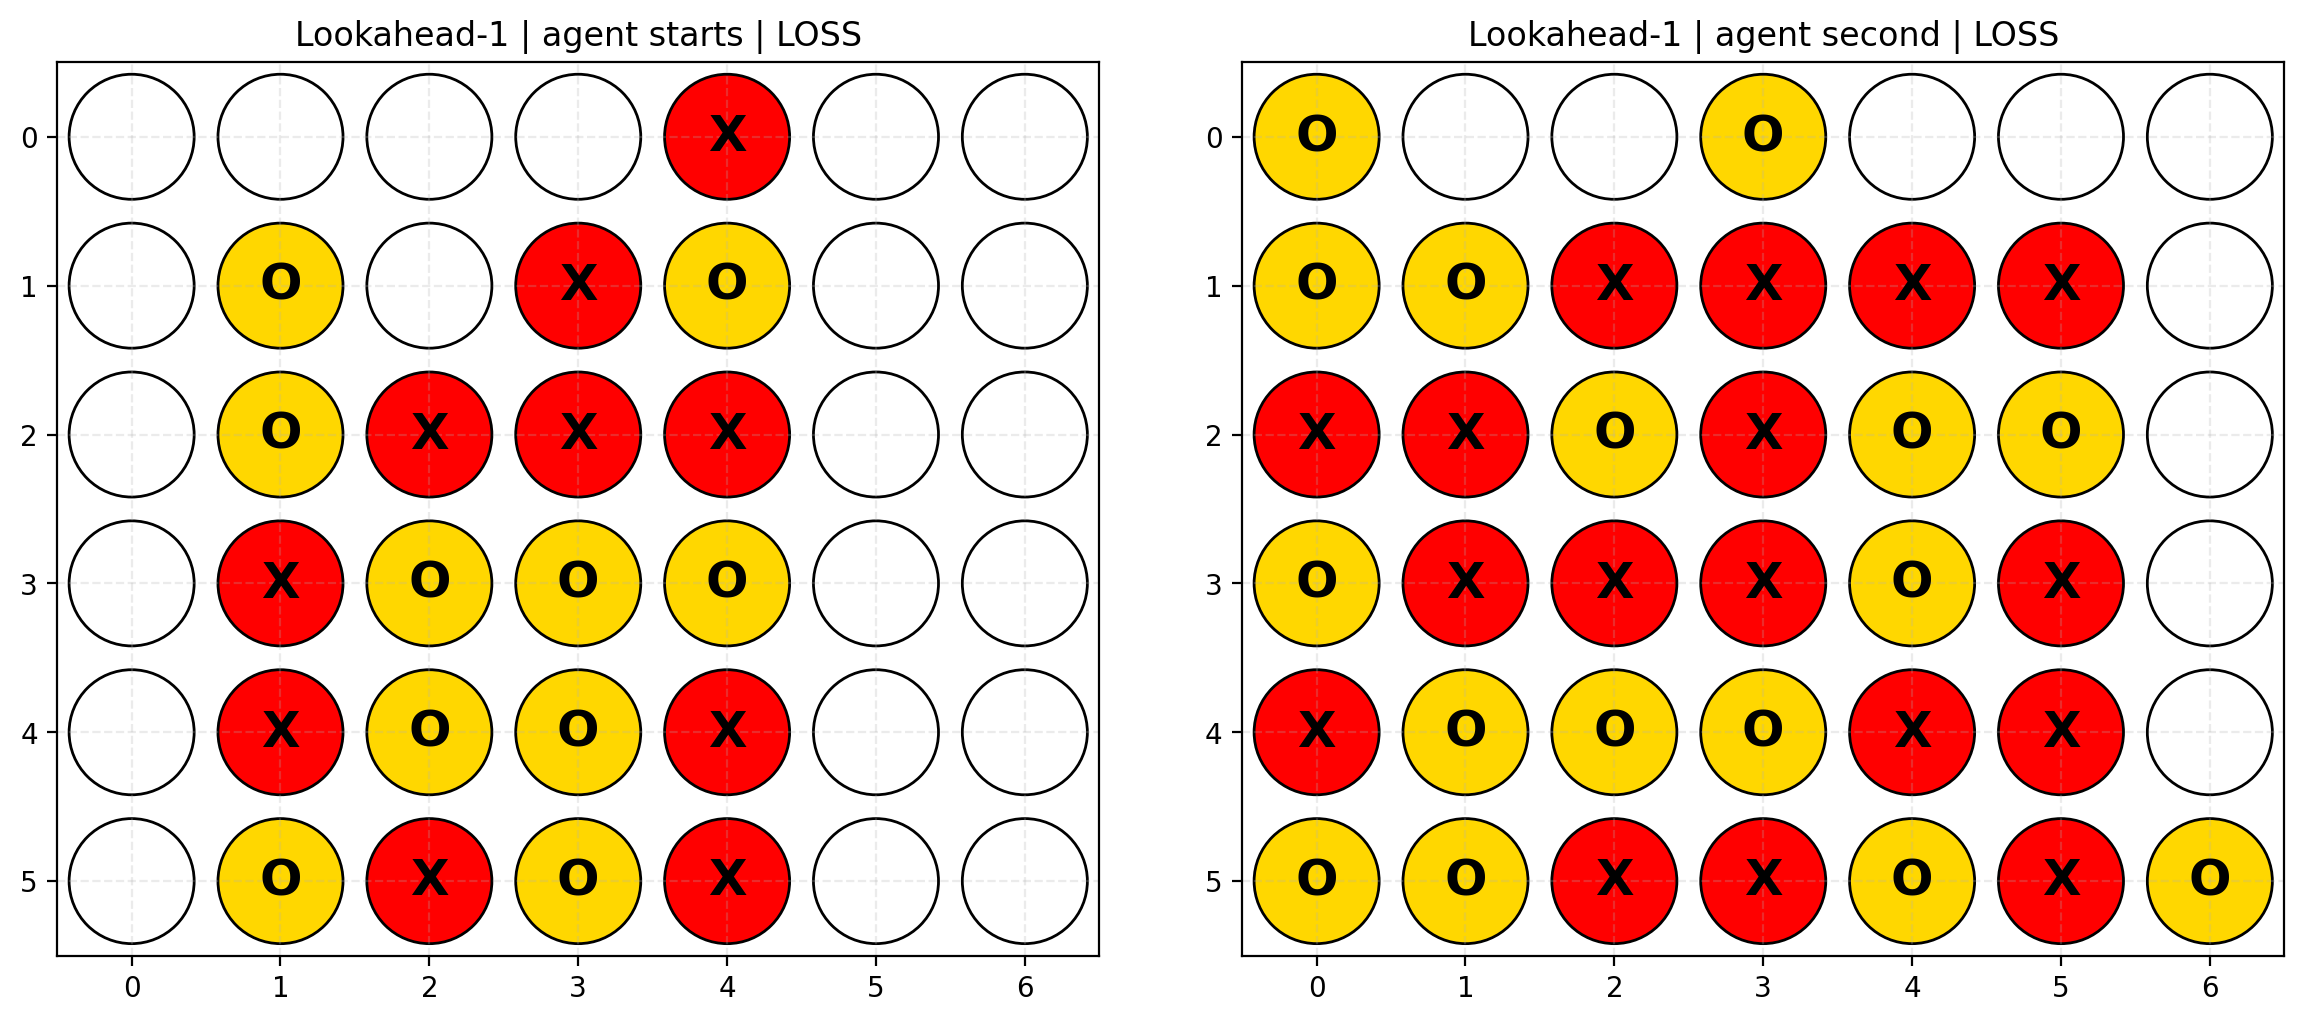

In [16]:
display_final_boards_DQN(agent, ["Lookahead-1"], lookahead = Lookahead)

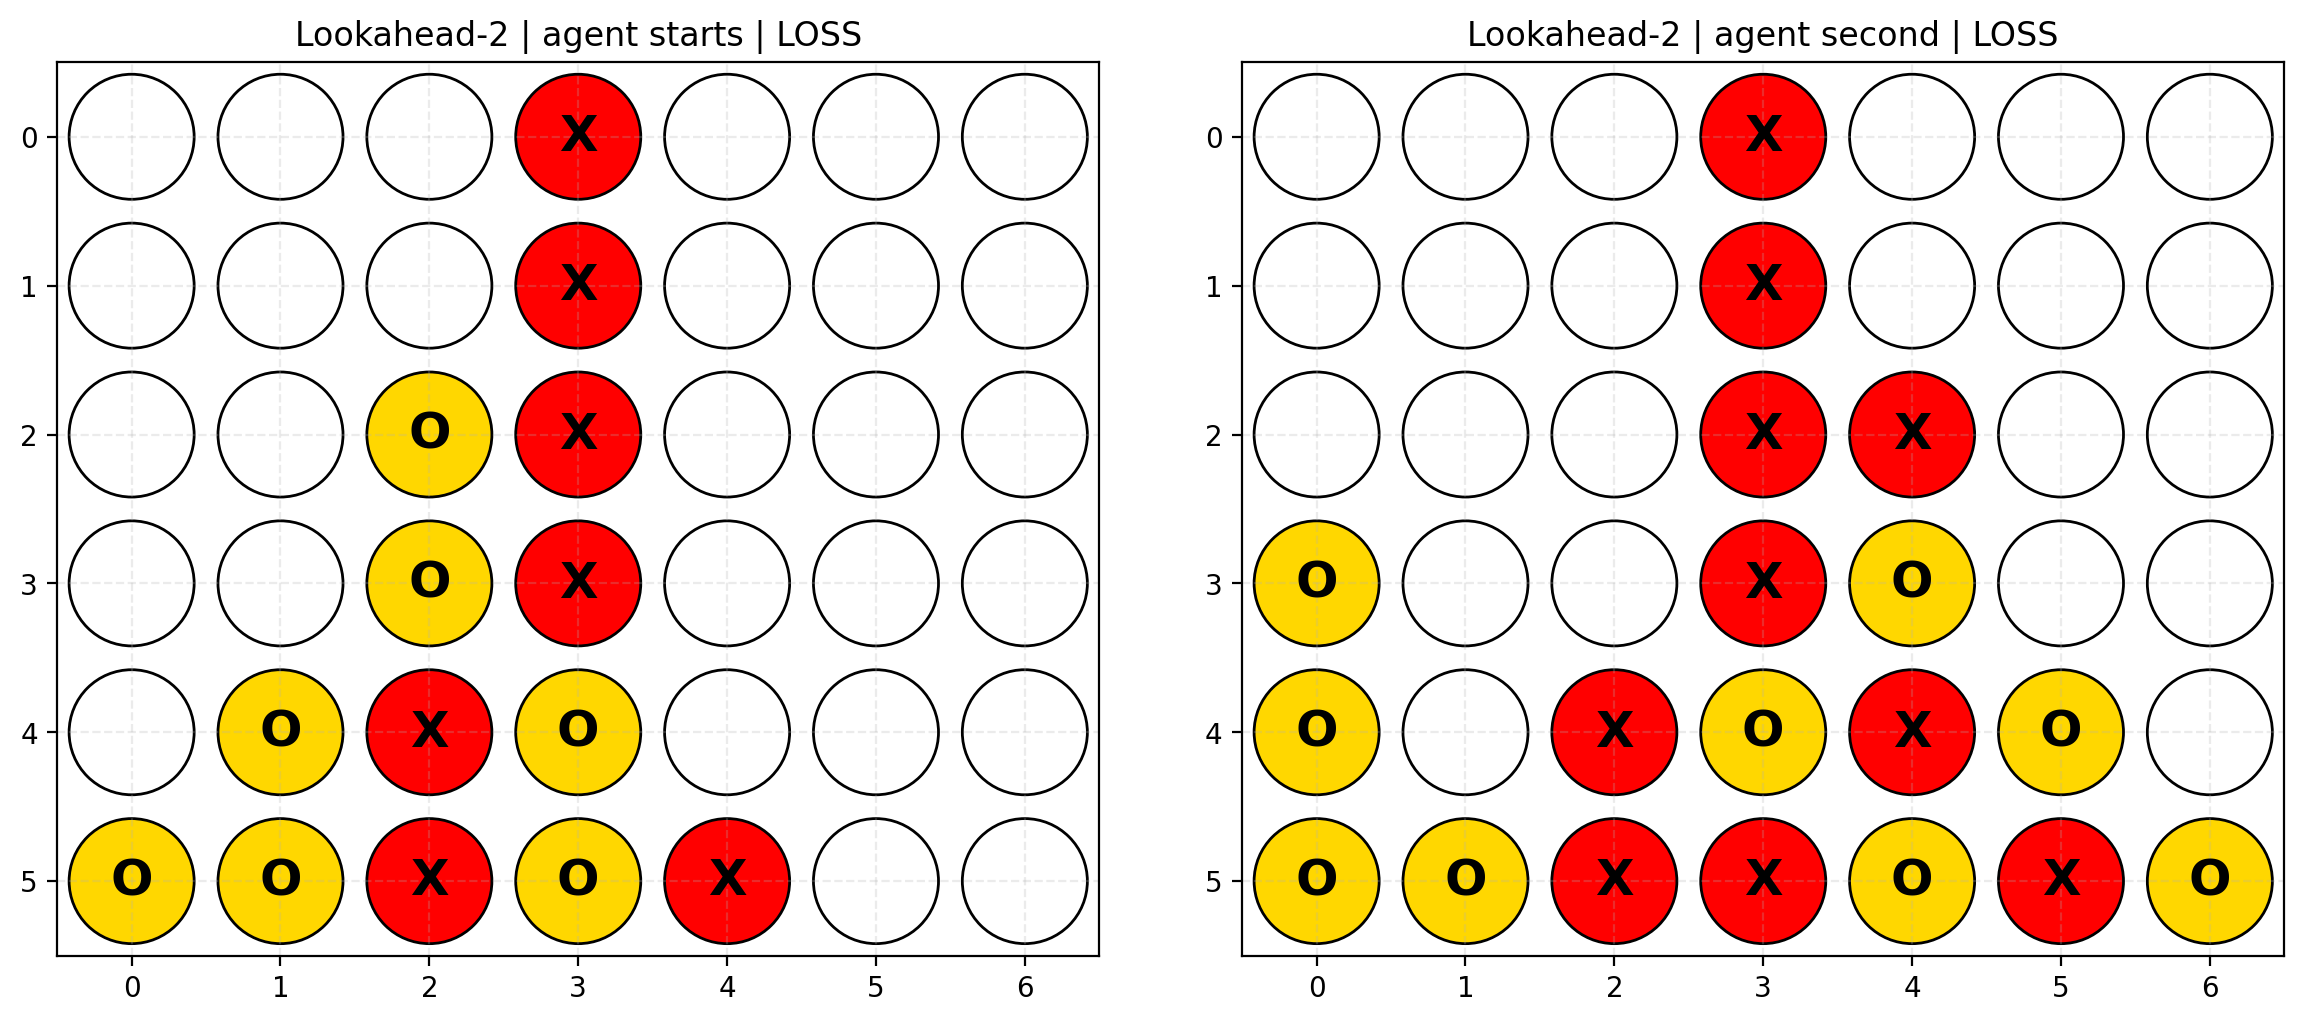

In [17]:
display_final_boards_DQN(agent, ["Lookahead-2"], lookahead = Lookahead)

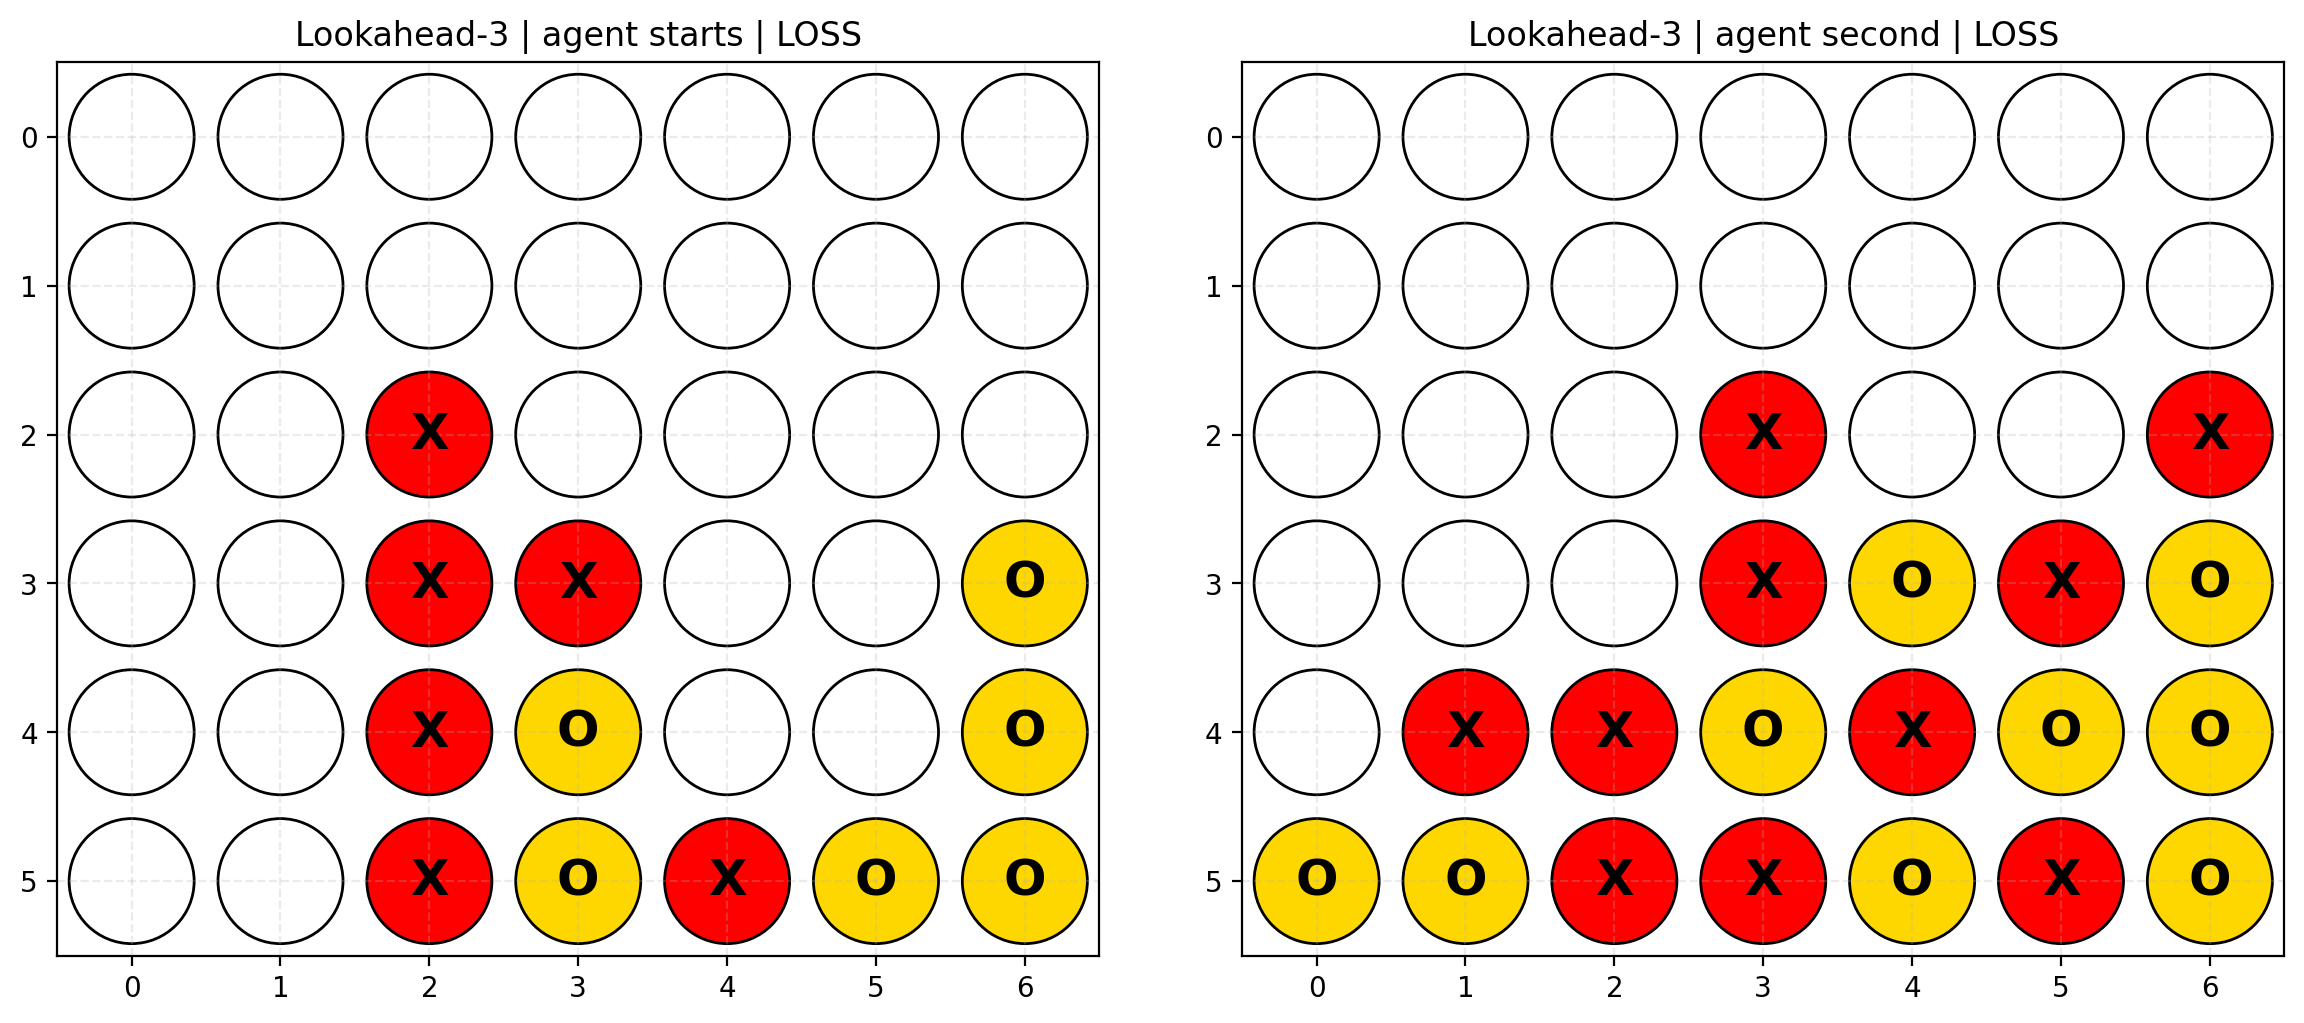

In [18]:
display_final_boards_DQN(agent, ["Lookahead-3"], lookahead = Lookahead)

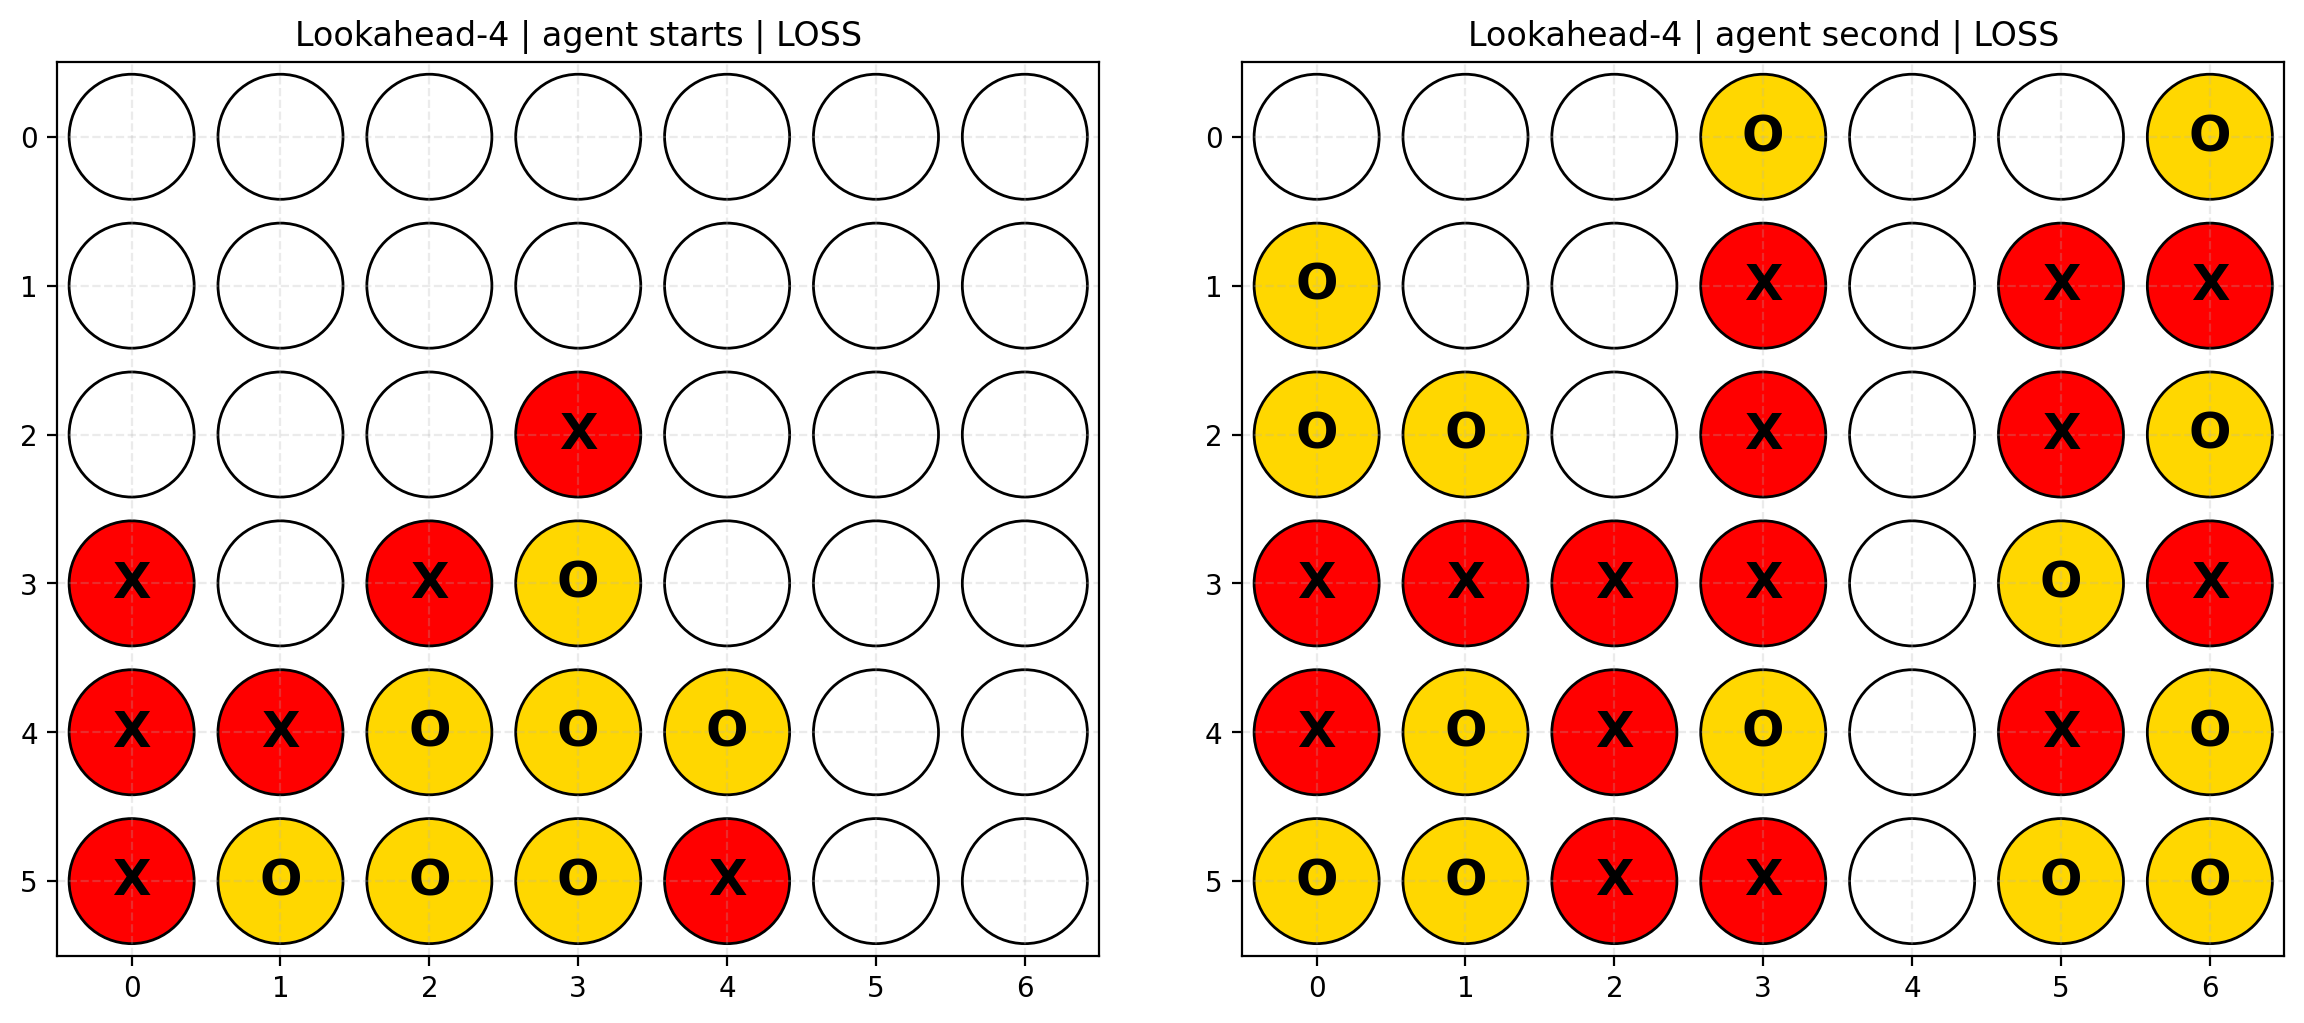

In [19]:
display_final_boards_DQN(agent, ["Lookahead-4"], lookahead = Lookahead)

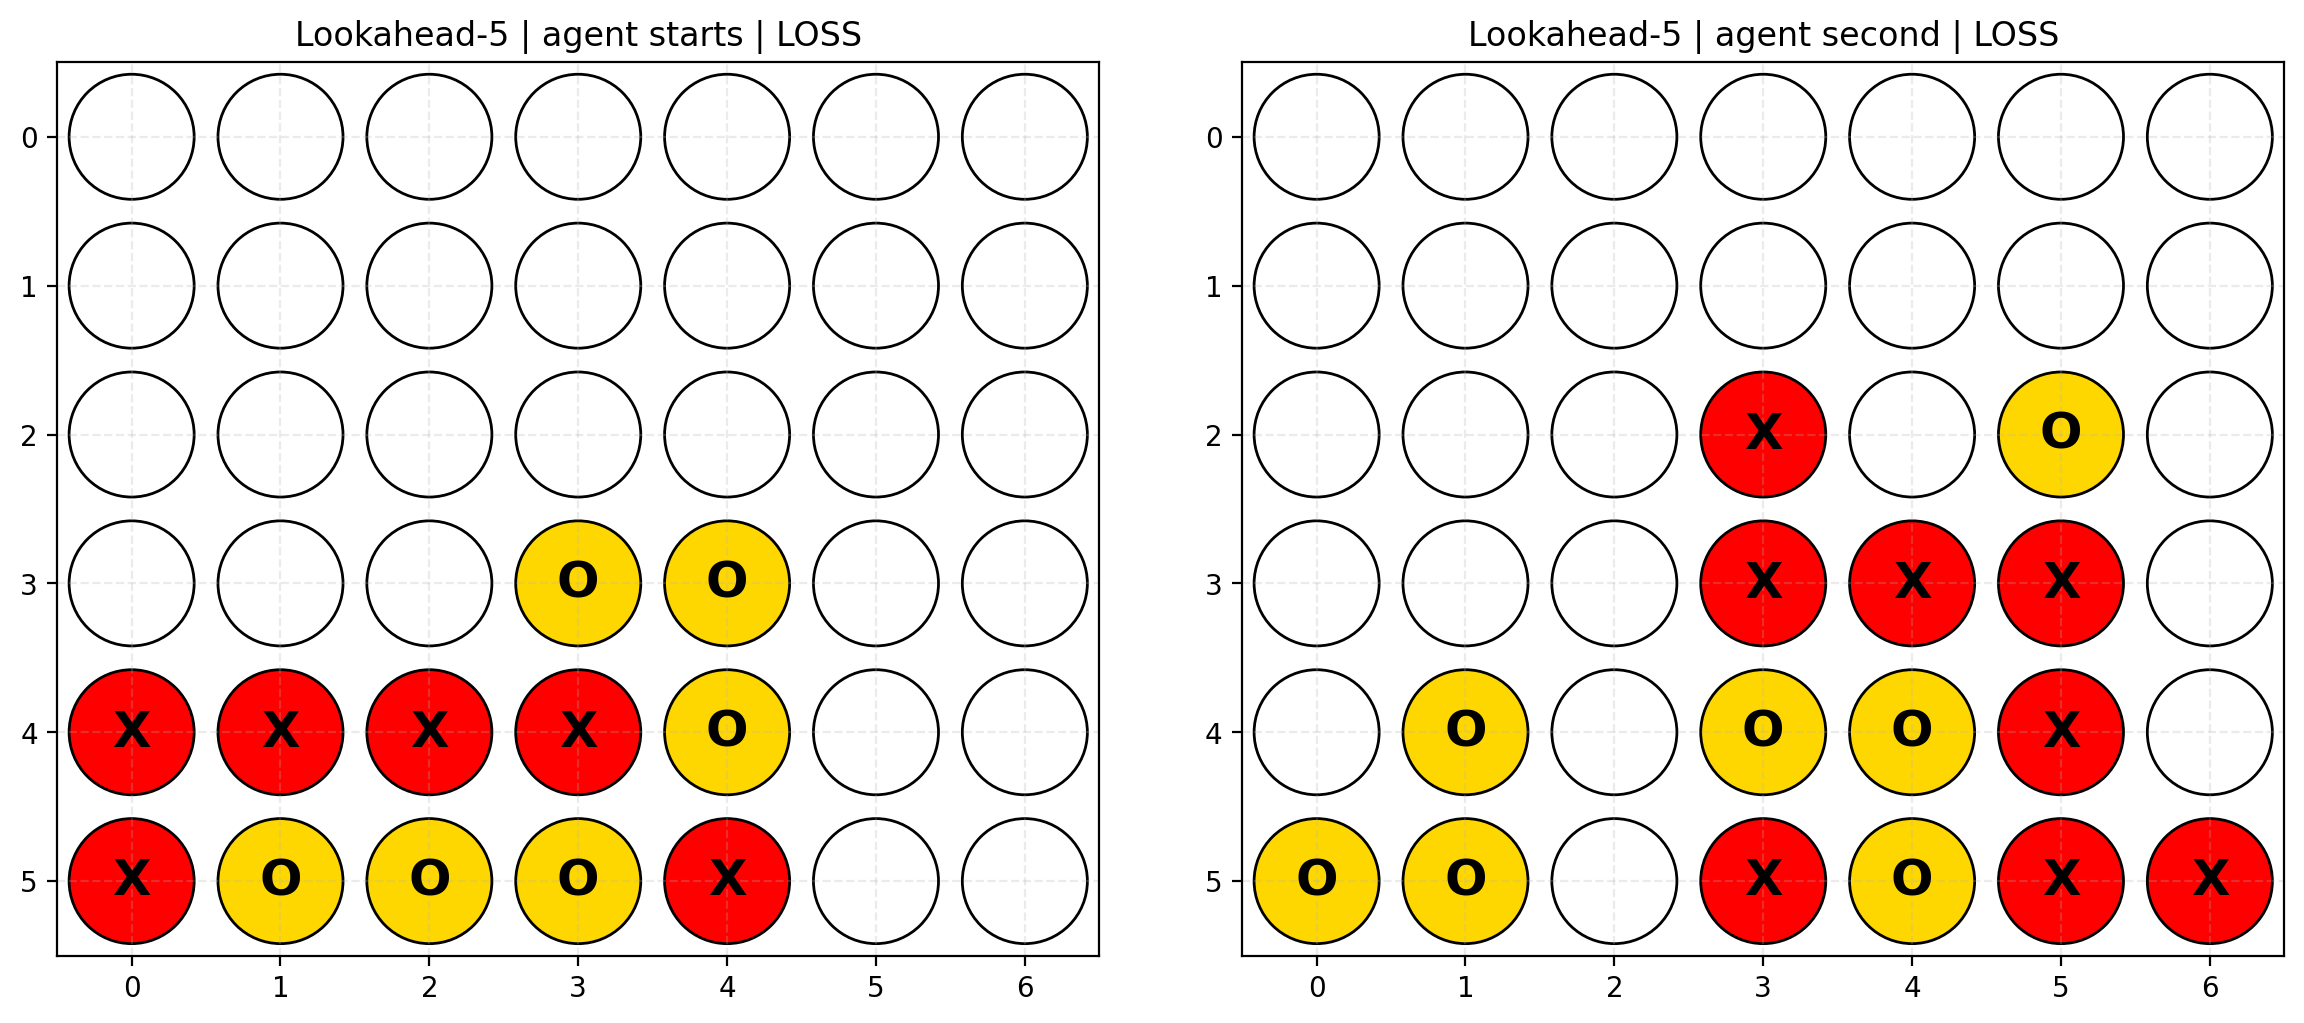

In [20]:
display_final_boards_DQN(agent, ["Lookahead-5"], lookahead = Lookahead)

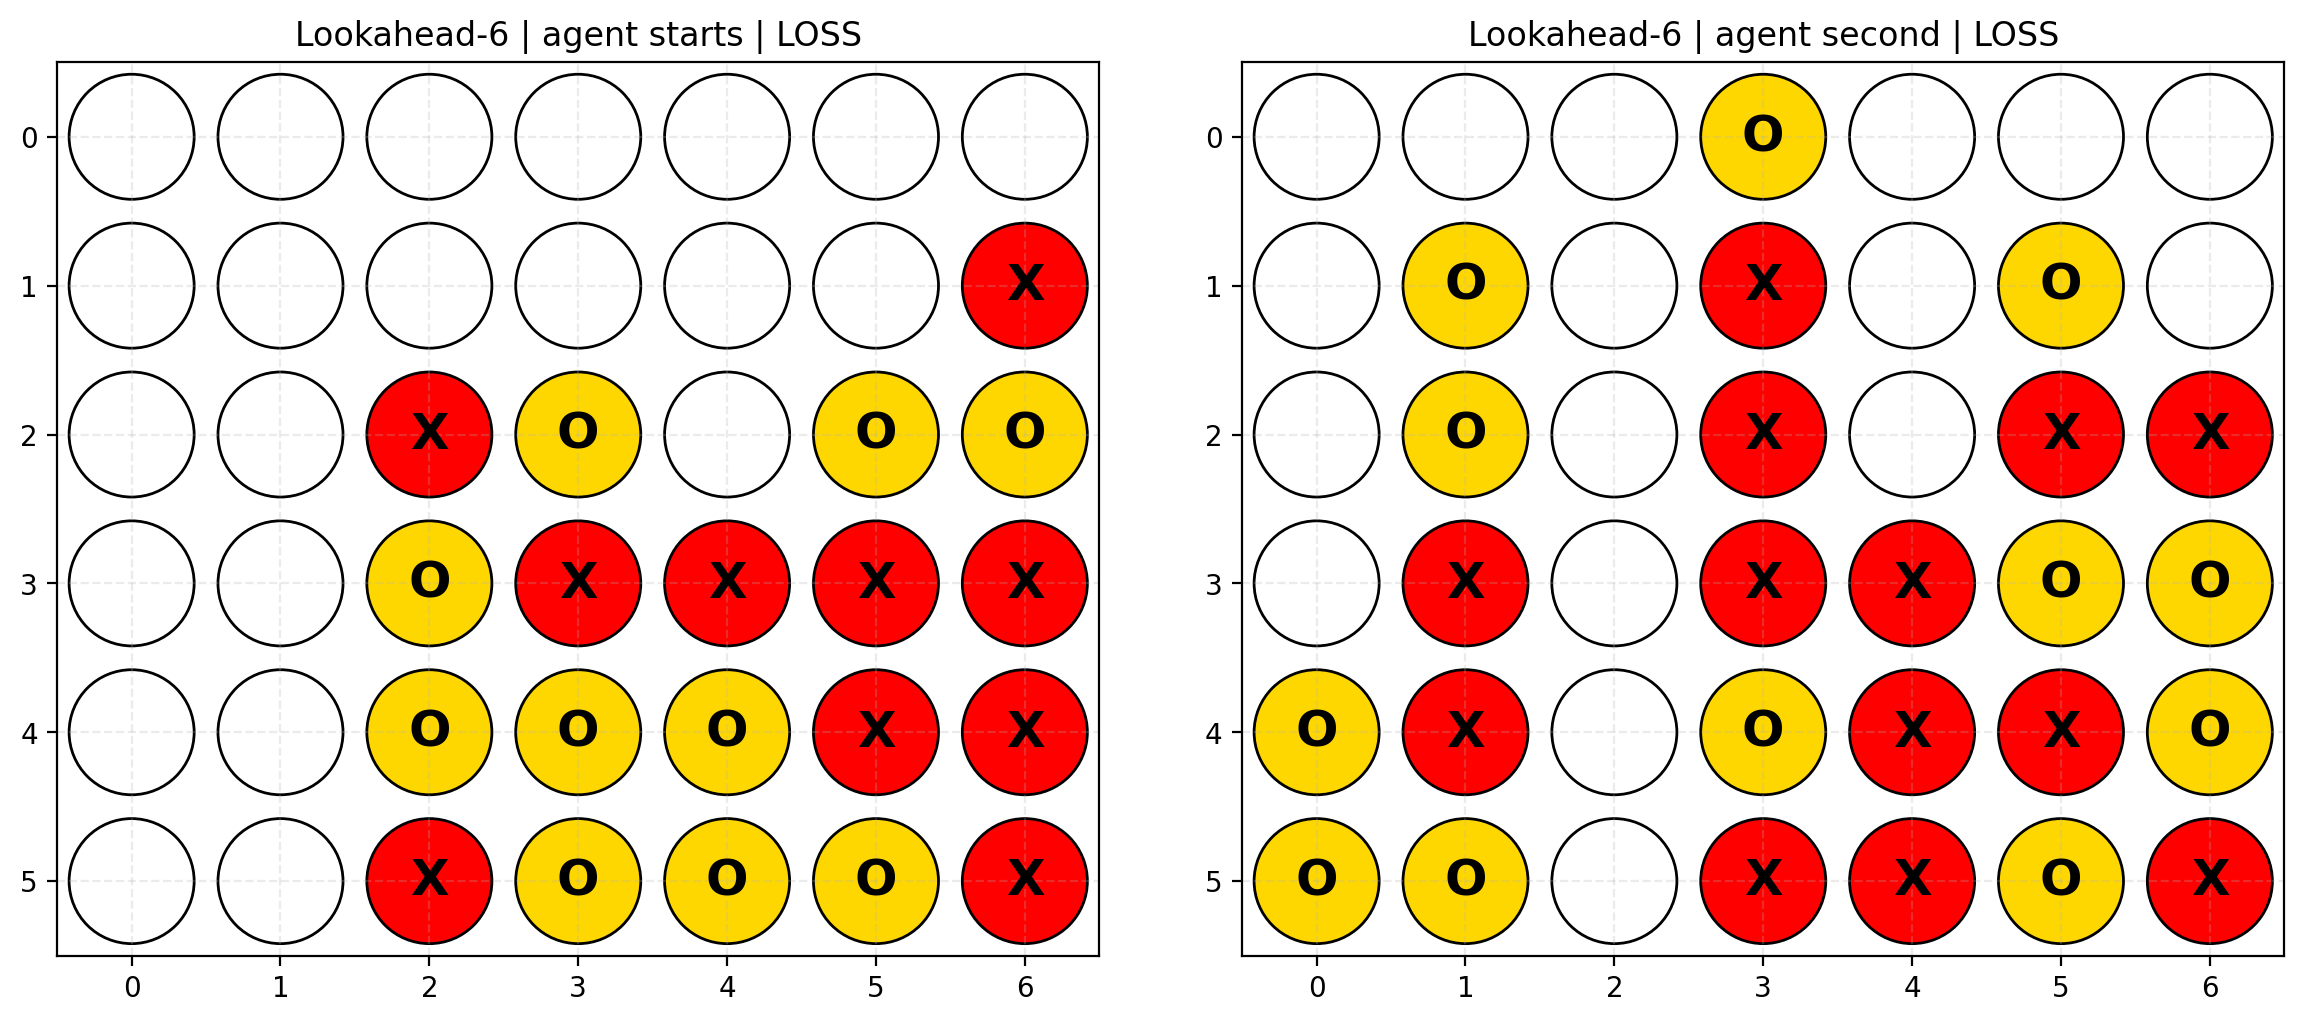

In [21]:
display_final_boards_DQN(agent, ["Lookahead-6"], lookahead = Lookahead)

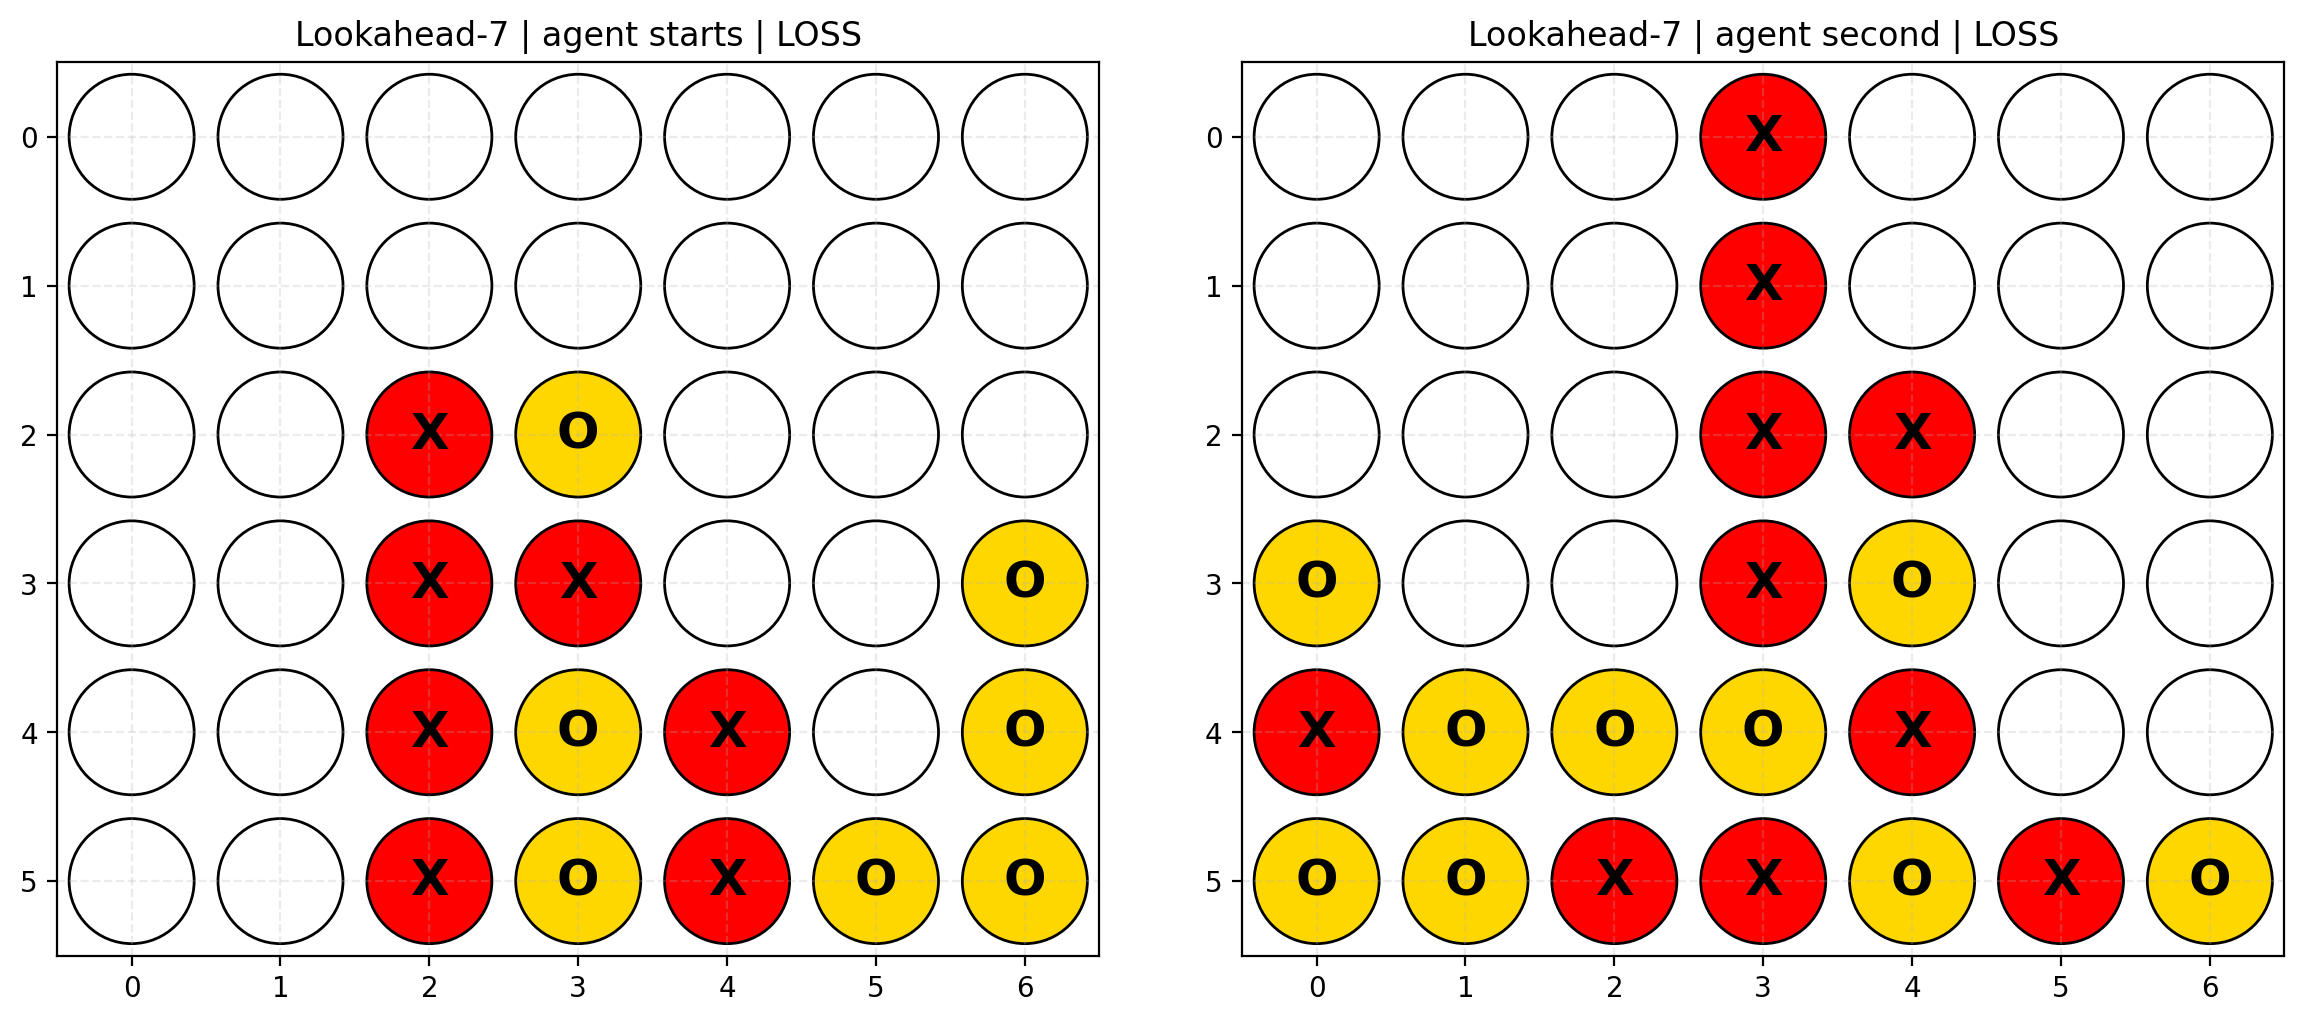

In [22]:
display_final_boards_DQN(agent, ["Lookahead-7"], lookahead = Lookahead)

# DONE

In [23]:
total_end_time = time.time()
total_elapsed = (total_end_time - begin_start_time) / 3600
print(f"Evaluation completed in {total_elapsed:.1f} hours")

Evaluation completed in 0.0 hours
